In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import ConfusionMatrixDisplay, f1_score, make_scorer, confusion_matrix, mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve,precision_recall_curve, auc

## UKBB ##

In [113]:
# Keep only the features which are present in validation set

training_df=pd.read_csv('training_df_3class.csv',index_col=0)
test_df=pd.read_csv('test_df_3class.csv',index_col=0)
training_df.head()

training_df['time_to_MN']=np.where(training_df['year_MN'].notnull(),training_df['year_MN']-training_df['year_of_assessment'],np.nan)
test_df['time_to_MN']=np.where(test_df['year_MN'].notnull(),test_df['year_MN']-test_df['year_of_assessment'],np.nan)

#cols_to_keep=['sex','RBC','Hbconc', 'MCV','MCHb','MCHbconc', 'RDW', 'platelet', 'plateletcrit', 'MPV',
              #'lymphocyte','monocyte', 'neutrophil', 'eosinophil','basophil','nucRBC', 'reticulocyte', 'MRV','MspCV',
              #'immret','age','giant_plt','CH']

# Removing the BORUTA/SHAP mandated insignificant features 

#cols_to_keep=['RBC','Hbconc', 'MCV','MCHb', 'RDW', 'platelet', 'plateletcrit',
               #'lymphocyte','monocyte', 'neutrophil', 'eosinophil', 'reticulocyte', 'MRV','MspCV',
               #'immret','age','giant_plt','CH']

# Selecting the features for the model with best AUC-2 from feature permutations

#cols_to_keep=['MCV','MCHb', 'platelet','lymphocyte','monocyte', 'neutrophil', 'eosinophil', 'reticulocyte', 'age','giant_plt','CH']

# Best model with least possible features? 

#cols_to_keep=['MCV', 'platelet', 'neutrophil', 'eosinophil', 'reticulocyte', 'age','giant_plt','CH']

# Features used in ASH model
cols_to_keep=['RBC','Hbconc', 'MCV', 'RDW', 'platelet','plateletcrit','lymphocyte','monocyte', 'neutrophil', 
              'eosinophil', 'reticulocyte','age','giant_plt','CH']


training_df_evaluate=training_df[cols_to_keep]
test_df_evaluate=test_df[cols_to_keep]

X_train=training_df_evaluate.drop(columns=['CH'])
y_train=training_df_evaluate[['CH']]
X_test=test_df_evaluate.drop(columns=['CH'])
y_test=test_df_evaluate[['CH']]

### Training cohort statistics ###

In [3]:
print(len(training_df))
print(training_df['age'].mean(),training_df['age'].std())
print((training_df['sex']==1).sum(),(training_df['sex']==0).sum())
print((training_df['MN']==0).sum(),(training_df['MN']==1).sum())

369260
57.02794846449655 8.09024457802773
169305 199955
367943 1317


In [4]:
training_df['CHRS'].value_counts()

CHRS
0.0     346270
8.0       7402
7.5       6694
8.5       3002
9.0       2065
9.5       1846
10.0       820
10.5       501
11.0       285
11.5       118
12.0       107
12.5        62
13.0        37
13.5        32
14.0        14
14.5         3
15.5         1
15.0         1
Name: count, dtype: int64

In [8]:
# Define conditions
anemia = ((training_df['sex'] == 0) & (training_df['Hbconc'] < 12)) | ((training_df['sex'] == 1) & (training_df['Hbconc'] < 13))
neutropenia = training_df['neutrophil'] < 1.8
thrombocytopenia = training_df['platelet'] < 150
erythro = training_df['Hbconc'] >= 17
neutro = training_df['neutrophil'] >= 6
thrombo = training_df['platelet'] >= 450
mono = training_df['monocyte'] >= 1
eosin = training_df['eosinophil'] >=0.5
baso=training_df['basophil']>=0.3

# CH
CH=training_df['CHRS']>0

# Cytopenia
cytopenia = anemia | neutropenia | thrombocytopenia

# Cytoses
cytoses= erythro| neutro| thrombo| mono| eosin| baso

# CCUS
CCUS = training_df[CH&cytopenia].shape[0]

# cytoses +CH
cytoCH= training_df[CH&cytoses].shape[0]

# CHIP
CHIP = training_df[CH&(~cytopenia)&(~cytoses)].shape[0]

# cytoses+cytopenia+CH
bothCH= training_df[CH&cytopenia&cytoses].shape[0]

# Print results
print("Number with CH:", CH.sum())
print("Number with CCUS:", CCUS)
print("Number with Cytoses:", cytoCH)
print("Number with CHIP:", CHIP)
print("Number with CH, cytopenia and cytoses:", bothCH)

Number with CH: 22990
Number with CCUS: 1743
Number with Cytoses: 3826
Number with CHIP: 17725
Number with CH, cytopenia and cytoses: 304


In [9]:
# 1. Actual number of high-risk individuals in the training set
hirisk_true = (training_df['CHRS'] >= 12.5).sum()
intermediate_true = ((training_df['CHRS'] >= 10)&(training_df['CHRS'] < 12.5)).sum()
lowrisk_true = ((training_df['CHRS'] > 0)&(training_df['CHRS'] < 10)).sum()
norisk_true = (training_df['CHRS'] == 0).sum()

hirisk_true,intermediate_true,lowrisk_true,norisk_true

(150, 1831, 21009, 346270)

In [8]:
print(((training_df['CHRS'] >= 12.5)&(training_df['MN']==0)).sum())
print(((training_df['CHRS'] >= 10)&(training_df['CHRS'] < 12.5)&(training_df['MN']==0)).sum())
print(((training_df['CHRS'] > 0)&(training_df['CHRS'] < 10)&(training_df['MN']==0)).sum())
print(((training_df['CHRS'] == 0)&(training_df['MN']==0)).sum())


print(((training_df['CHRS'] >= 12.5)&(training_df['MN']==1)).sum())
print(((training_df['CHRS'] >= 10)&(training_df['CHRS'] < 12.5)&(training_df['MN']==1)).sum())
print(((training_df['CHRS'] > 0)&(training_df['CHRS'] < 10)&(training_df['MN']==1)).sum())
print(((training_df['CHRS'] == 0)&(training_df['MN']==1)).sum())

69
1662
20834
345378
81
169
175
892


In [9]:
training_df['CH'].value_counts()

CH
0.0    364090
1.0      4876
2.0       294
Name: count, dtype: int64

In [10]:
(training_df['CH_score']>4).sum()

5170

In [52]:
def stats(df,feature):
    q1 =df[feature].describe()['25%']
    q2 = df[feature].describe()['50%']
    q3 = df[feature].describe()['75%']

    return q1,q2,q3

features=['RBC','Hbconc', 'MCV', 'RDW', 'platelet','plateletcrit','lymphocyte','monocyte', 'neutrophil', 
              'eosinophil', 'reticulocyte','age']

print('feature, Q1, median, Q2:')
for i in features:
    q1,q2,q3 = stats(X_train,i)
    print(i,q1,q2,q3)

feature, Q1, median, Q2:
RBC 4.235000000000001 4.503 4.79
Hbconc 13.32 14.15 15.03
MCV 88.5 91.2 93.86
RDW 12.9 13.34 13.86
platelet 213.8 248.2 287.3
plateletcrit 0.201 0.229 0.261
lymphocyte 1.5 1.88 2.3
monocyte 0.36 0.45 0.57
neutrophil 3.27 4.02 4.97
eosinophil 0.1 0.14 0.21
reticulocyte 0.043 0.057 0.074
age 50.5 58.25 63.66666666666674


In [14]:
X_train['giant_plt'].value_counts()

giant_plt
0    284364
1     84896
Name: count, dtype: int64

### Test cohort statistics ###

In [10]:
print(len(test_df))
print(test_df['age'].mean(),test_df['age'].std())
print((test_df['sex']==1).sum(),(test_df['sex']==0).sum())
print((test_df['MN']==0).sum(),(test_df['MN']==1).sum())

92316
57.02063744818522 8.058452140043519
42314 50002
91981 335


In [11]:
# Define conditions
anemia = ((test_df['sex'] == 0) & (test_df['Hbconc'] < 12)) | ((test_df['sex'] == 1) & (test_df['Hbconc'] < 13))
neutropenia = test_df['neutrophil'] < 1.8
thrombocytopenia = test_df['platelet'] < 150
erythro = test_df['Hbconc'] >= 17
neutro = test_df['neutrophil'] >= 6
thrombo = test_df['platelet'] >= 450
mono = test_df['monocyte'] >= 1
eosin = test_df['eosinophil'] >=0.5
baso= test_df['basophil']>=0.3

# CH
CH= test_df['CHRS']>0

# Cytopenia
cytopenia = anemia | neutropenia | thrombocytopenia

# Cytoses
cytoses= erythro| neutro| thrombo| mono| eosin| baso

# CCUS
CCUS = test_df[CH&cytopenia].shape[0]

# cytoses +CH
cytoCH= test_df[CH&cytoses].shape[0]

# CHIP
CHIP = test_df[CH&(~cytopenia)&(~cytoses)].shape[0]

# cytoses+cytopenia+CH
bothCH= test_df[CH&cytopenia&cytoses].shape[0]

# Print results
print("Number with CH:", CH.sum())
print("Number with CCUS:", CCUS)
print("Number with Cytoses:", cytoCH)
print("Number with CHIP:", CHIP)
print("Number with CH, cytopenia and cytoses:", bothCH)

Number with CH: 5887
Number with CCUS: 458
Number with Cytoses: 961
Number with CHIP: 4555
Number with CH, cytopenia and cytoses: 87


In [55]:
# 1. Actual number of high-risk individuals in the training set
hirisk_true = (test_df['CHRS'] >= 12.5).sum()
intermediate_true = ((test_df['CHRS'] >= 10)&(test_df['CHRS'] < 12.5)).sum()
lowrisk_true = ((test_df['CHRS'] > 0)&(test_df['CHRS'] < 10)).sum()
norisk_true = (test_df['CHRS'] == 0).sum()

hirisk_true,intermediate_true,lowrisk_true,norisk_true

(42, 462, 5383, 86429)

In [56]:
test_df['CH'].value_counts()

CH
0.0    91024
1.0     1219
2.0       73
Name: count, dtype: int64

In [57]:
print(((test_df['CHRS'] >= 12.5)&(test_df['MN']==0)).sum())
print(((test_df['CHRS'] >= 10)&(test_df['CHRS'] < 12.5)&(test_df['MN']==0)).sum())
print(((test_df['CHRS'] > 0)&(test_df['CHRS'] < 10)&(test_df['MN']==0)).sum())
print(((test_df['CHRS'] == 0)&(test_df['MN']==0)).sum())


print(((test_df['CHRS'] >= 12.5)&(test_df['MN']==1)).sum())
print(((test_df['CHRS'] >= 10)&(test_df['CHRS'] < 12.5)&(test_df['MN']==1)).sum())
print(((test_df['CHRS'] > 0)&(test_df['CHRS'] < 10)&(test_df['MN']==1)).sum())
print(((test_df['CHRS'] == 0)&(test_df['MN']==1)).sum())

22
419
5332
86208
20
43
51
221


In [58]:
def stats(df,feature):
    q1 =df[feature].describe()['25%']
    q2 = df[feature].describe()['50%']
    q3 = df[feature].describe()['75%']

    return q1,q2,q3

features=['RBC','Hbconc', 'MCV', 'RDW', 'platelet','plateletcrit','lymphocyte','monocyte', 'neutrophil', 
              'eosinophil', 'reticulocyte','age']

print('feature, Q1, median, Q2:')
for i in features:
    q1,q2,q3 = stats(X_test,i)
    print(i,q1,q2,q3)

feature, Q1, median, Q2:
RBC 4.234 4.504 4.788
Hbconc 13.33 14.15 15.03
MCV 88.53 91.21 93.87
RDW 12.9 13.34 13.86
platelet 213.4 248.0 287.3
plateletcrit 0.201 0.229 0.261
lymphocyte 1.51 1.88 2.3
monocyte 0.37 0.45 0.57
neutrophil 3.27 4.01 4.96
eosinophil 0.1 0.14 0.21
reticulocyte 0.043 0.057 0.074
age 50.583333333333485 58.25 63.66666666666652


In [59]:
X_test['giant_plt'].value_counts()

giant_plt
0    71214
1    21102
Name: count, dtype: int64

In [61]:
positive=test_df.loc[test_df['CH']==2]
equivocal=test_df.loc[test_df['CH']==1]
negative=test_df.loc[test_df['CH']==0]
stats(positive,'age'),stats(equivocal,'age'),stats(negative,'age')

((61.25, 65.08333333333326, 67.25),
 (57.833333333333485, 63.08333333333326, 66.66666666666652),
 (50.5, 58.16666666666652, 63.58333333333326))

In [63]:
print((positive['sex']==1).sum(),(positive['sex']==0).sum())
print((equivocal['sex']==1).sum(),(equivocal['sex']==0).sum())
print((negative['sex']==1).sum(),(negative['sex']==0).sum())

37 36
606 613
41671 49353


In [67]:
# CHIP
# Define conditions
anemia = ((positive['sex'] == 0) & (positive['Hbconc'] < 12)) | ((positive['sex'] == 1) & (positive['Hbconc'] < 13))
neutropenia = positive['neutrophil'] < 1.8
thrombocytopenia =positive['platelet'] < 150
CH = positive['CHRS']>0
# Cytopenia
cytopenia = anemia | neutropenia | thrombocytopenia
print(positive[CH].shape[0],positive[CH&cytopenia].shape[0])

73 19


In [68]:
# CHIP
# Define conditions
anemia = ((equivocal['sex'] == 0) & (equivocal['Hbconc'] < 12)) | ((equivocal['sex'] == 1) & (equivocal['Hbconc'] < 13))
neutropenia = equivocal['neutrophil'] < 1.8
thrombocytopenia =equivocal['platelet'] < 150
CH = equivocal['CHRS']>0
# Cytopenia
cytopenia = anemia | neutropenia | thrombocytopenia
print(equivocal[CH].shape[0],equivocal[CH&cytopenia].shape[0])

1219 114


In [69]:
# CHIP
# Define conditions
anemia = ((negative['sex'] == 0) & (negative['Hbconc'] < 12)) | ((negative['sex'] == 1) & (negative['Hbconc'] < 13))
neutropenia = negative['neutrophil'] < 1.8
thrombocytopenia =negative['platelet'] < 150
CH = negative['CHRS']>0
# Cytopenia
cytopenia = anemia | neutropenia | thrombocytopenia
print(negative[CH].shape[0],negative[CH&cytopenia].shape[0])

4595 325


### load model ###

In [114]:
# Load the saved model
import pickle
with open("models/3class_BRF_giantplt_ASH_latest.pkl", "rb") as f:
    loaded_package = pickle.load(f)

loaded_model = loaded_package['model']
loaded_features = loaded_package['features']
loaded_thresholds = loaded_package['optimal_thresholds']
loaded_classes = loaded_package['classes']

In [115]:
loaded_features

['RBC',
 'Hbconc',
 'MCV',
 'RDW',
 'platelet',
 'plateletcrit',
 'lymphocyte',
 'monocyte',
 'neutrophil',
 'eosinophil',
 'reticulocyte',
 'age',
 'giant_plt']

### make prediction ###

In [116]:
# Get prediction
y_pred_proba=loaded_model.predict_proba(X_test)
threshold_array=np.array([loaded_thresholds[c] for c in loaded_classes])

y_pred_custom=[]

for prob_vector in y_pred_proba:
    passing_classes=np.where(prob_vector>=threshold_array)[0]
    if passing_classes.size>0:
        passing_margin=prob_vector[passing_classes]-threshold_array[passing_classes]
        max_passing_index=np.argmax(passing_margin)
        chosen_class_index=passing_classes[max_passing_index]
        chosen_class=loaded_classes[chosen_class_index]
    else:
        chosen_class_index=np.argmax(prob_vector)
        chosen_class=loaded_classes[chosen_class_index]
    
    y_pred_custom.append(chosen_class)

y_pred_custom = np.array(y_pred_custom)

#  Indices where the model predicted "CH positive with MN" (label 2)
mask_2 = (y_pred_custom == 2)
n_rows_2 = np.where(mask_2)[0]

#  Indices where the model predicted "CH positive without MN" (label 1)
mask_1 = (y_pred_custom == 1)
n_rows_1 = np.where(mask_1)[0]

#  Indices where the model predicted "Everyone else" (label 0)
mask_0 = (y_pred_custom == 0)
n_rows_0 = np.where(mask_0)[0]

# Subset of X_test corresponding to predicted positive
predicted_class2_df = test_df.iloc[n_rows_2]
predicted_class1_df = test_df.iloc[n_rows_1]
predicted_class0_df = test_df.iloc[n_rows_0]

# Print the stats 
print("Number of people predicted in class 2:",len(predicted_class2_df),len(predicted_class2_df)*100/len(y_pred_custom))
print("Number of people predicted in class 1:",len(predicted_class1_df),len(predicted_class1_df)*100/len(y_pred_custom))
print("Number of people predicted in class 0:",len(predicted_class0_df),len(predicted_class0_df)*100/len(y_pred_custom))

Number of people predicted in class 2: 10367 11.229905975128904
Number of people predicted in class 1: 31851 34.50214480696737
Number of people predicted in class 0: 50098 54.26794921790372


In [117]:
predicted_class0_df.loc[predicted_class0_df['CH']==2][['age','Hbconc','MCV','RDW','platelet','neutrophil','CHRS','CH_score']]

,age,Hbconc,MCV,RDW,platelet,neutrophil,CHRS,CH_score
254491,47.916667,15.30,92.90,13.10,242.0,4.10,8.5,4.5
305218,56.000000,17.06,86.51,13.55,251.5,3.57,11.5,7.5
371983,56.916667,13.80,89.60,12.70,324.0,2.20,9.0,5.0



--- Plotting ROC-AUC Curve ---


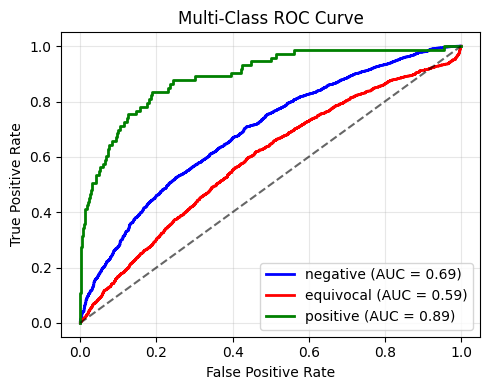

In [90]:
accuracy = accuracy_score(y_test, y_pred_custom)
#print(f"\nAccuracy Score (Optimal OvR Thresholds): {accuracy:.4f}")
#print("\nClassification Report (Optimal OvR Thresholds):")
#print(classification_report(y_HMDR, y_pred_custom))

n_classes=len(loaded_classes)
class_names = {
    0: "negative",
    1: "equivocal",
    2: "positive"
}
#print(n_classes,loaded_classes)
# --- 5b. Plot ROC-AUC Curve (Uses y_proba_test) ---
print("\n--- Plotting ROC-AUC Curve ---")
y_test_bin = label_binarize(y_test, classes=loaded_classes)
colors = ['blue', 'red', 'green', 'brown']

plt.figure(figsize=(5, 4))
for i in range(n_classes):
    fpr, tpr, thresholds = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i % len(colors)], lw=2, label=f'{class_names[loaded_classes[i]]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='black', alpha=0.6)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve")
plt.legend(loc="lower right",fontsize=10)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figures/roc_auc_ukb.png", dpi=300, bbox_inches='tight')
plt.show()

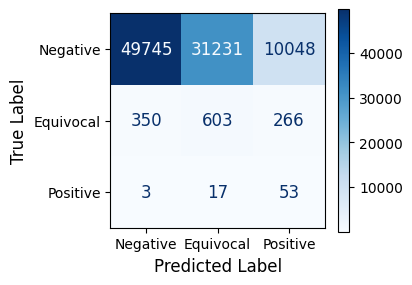

In [36]:
# --- 5c. Plot Confusion Matrix (Uses y_pred_optimal_threshold) ---
#print("\n--- Plotting Confusion Matrix ---")
cmap = sns.color_palette("Blues", as_cmap=True)
cm = confusion_matrix(y_test, y_pred_custom)
class_names = ["Negative", "Equivocal", "Positive"]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

plt.figure(figsize=(4, 3))
ax = plt.gca()
disp.plot(cmap=cmap, ax=ax, values_format='d', text_kw={"fontsize": 12})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)

plt.tight_layout()
plt.savefig("figures/confusion_matrix_ukb.png", dpi=300, bbox_inches='tight')
plt.show()

### Feature characteristics of predicted classes ###

In [32]:
def stats(df,feature):
    q1 =df[feature].describe()['25%']
    q2 = df[feature].describe()['50%']
    q3 = df[feature].describe()['75%']

    return q1,q2,q3

print('feature, Q1, median, Q2:')
for i in loaded_features:
    q1,q2,q3 = stats(predicted_class2_df,i)
    print(i,q1,q2,q3)

feature, Q1, median, Q2:
RBC 4.04 4.39 4.7225
Hbconc 12.5 13.43 14.47
MCV 86.14 90.7 95.0
RDW 13.75 14.7 15.48
platelet 194.1 248.5 320.0
plateletcrit 0.186 0.232 0.292
lymphocyte 1.4 1.79 2.26
monocyte 0.35 0.47 0.62
neutrophil 3.1 4.17 5.44
eosinophil 0.09 0.13 0.21
reticulocyte 0.045 0.061 0.082
age 56.75 62.41666666666652 66.41666666666652
giant_plt 0.0 0.0 1.0


In [33]:
predicted_class2_df['sex'].value_counts()

sex
0    5960
1    4407
Name: count, dtype: int64

In [34]:
# Define conditions
df=predicted_class2_df
anemia = ((df['sex'] == 0) & (df['Hbconc'] < 12)) | ((df['sex'] == 1) & (df['Hbconc'] < 13))
neutropenia = df['neutrophil'] < 1.8
thrombocytopenia = df['platelet'] < 150
erythro = df['Hbconc'] >= 17
neutro = df['neutrophil'] >= 6
thrombo = df['platelet'] >= 450
mono = df['monocyte'] >= 1
eosin = df['eosinophil'] >=0.5
baso= df['basophil']>=0.3

# CH
CH= df['CHRS']>0

# Cytopenia
cytopenia = anemia | neutropenia | thrombocytopenia

# Cytoses
cytoses= erythro| neutro| thrombo| mono| eosin| baso

# CCUS
CCUS = df[CH&cytopenia].shape[0]

# cytoses +CH
cytoCH= df[CH&cytoses].shape[0]

# CHIP
#CHIP = df[CH&(~cytopenia)&(~cytoses)].shape[0]
CHIP = df[CH&(~cytopenia)].shape[0]

# cytoses+cytopenia+CH
bothCH= df[CH&cytopenia&cytoses].shape[0]

# Print results
print("Number with CH:", CH.sum())
print("Number with CCUS:", CCUS)
print("Number with Cytoses:", cytoCH)
print("Number with CHIP:", CHIP)
print("Number with CH, cytopenia and cytoses:", bothCH)

Number with CH: 952
Number with CCUS: 266
Number with Cytoses: 298
Number with CHIP: 686
Number with CH, cytopenia and cytoses: 64


In [35]:
# 1. Actual number of high-risk individuals in the training set
hirisk_true = (df['CHRS'] >= 12.5).sum()
intermediate_true = ((df['CHRS'] >= 10)&(df['CHRS'] < 12.5)).sum()
lowrisk_true = ((df['CHRS'] > 0)&(df['CHRS'] < 10)).sum()
norisk_true = (df['CHRS'] == 0).sum()

hirisk_true,intermediate_true,lowrisk_true,norisk_true

(42, 259, 651, 9415)

### Plots of predicted class differences ###

/var/folders/01/qxbg7rcx0ds_3w3r_82z10zh0000gn/T/ipykernel_89476/510747037.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='class', y='MCV', data=df, inner=None, palette='pastel')


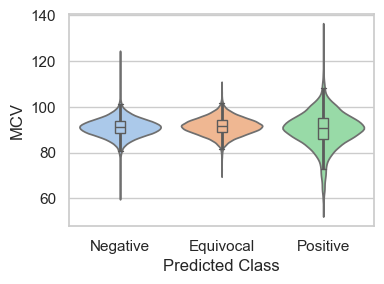

In [41]:
# Combine into one dataframe with a 'class' label
predicted_class0_df.loc[:,'class'] = 'Negative'
predicted_class1_df.loc[:,'class'] = 'Equivocal'
predicted_class2_df.loc[:,'class'] = 'Positive'

df = pd.concat([predicted_class0_df, predicted_class1_df, predicted_class2_df], ignore_index=True)

#df_sel=df.loc[df['CH_score']>0]

# Set style
sns.set(style="whitegrid")

# Create violin plot
plt.figure(figsize=(4,3))
sns.violinplot(x='class', y='MCV', data=df, inner=None, palette='pastel')

# Overlay box plot to show median and IQR
sns.boxplot(x='class', y='MCV', data=df, width=0.1, showcaps=True, boxprops={'facecolor':'None'},
            showfliers=False, whiskerprops={'linewidth':2})

#plt.title('Distribution of Pre-NGS molecular CH Scores Across Predicted Classes', fontsize=14)
plt.ylabel('MCV', fontsize=12)
plt.xlabel('Predicted Class', fontsize=12)
#plt.ylim(12,20)

plt.tight_layout()
plt.savefig("figures/MCV_predict.png", dpi=300, bbox_inches='tight')
plt.show()

### Prediction class analysis ###

In [118]:
# Check CHRS statistics of predicted labels 
   
# 1. Actual number of high-risk individuals in the test set
hirisk_true = (test_df['CHRS'] >= 12.5).sum()
intermediate_true = ((test_df['CHRS'] >= 10)&(test_df['CHRS'] < 12.5)).sum()
lowrisk_true = ((test_df['CHRS'] > 0)&(test_df['CHRS'] < 10)).sum()
norisk_true = (test_df['CHRS'] == 0).sum()

# 3. Among predicted positives, how many are high risk
hirisk_pred2 = (predicted_class2_df['CHRS'] >= 12.5).sum()
intermediate_pred2 = ((predicted_class2_df['CHRS'] >= 10)&(predicted_class2_df['CHRS'] < 12.5)).sum()
lowrisk_pred2 = ((predicted_class2_df['CHRS'] > 0)&(predicted_class2_df['CHRS'] < 10)).sum()
norisk_pred2 = (predicted_class2_df['CHRS'] == 0).sum()

hirisk_pred1 = (predicted_class1_df['CHRS'] >= 12.5).sum()
intermediate_pred1 = ((predicted_class1_df['CHRS'] >= 10)&(predicted_class1_df['CHRS'] < 12.5)).sum()
lowrisk_pred1 = ((predicted_class1_df['CHRS'] > 0)&(predicted_class1_df['CHRS'] < 10)).sum()
norisk_pred1 = (predicted_class1_df['CHRS'] == 0).sum()

hirisk_pred0 = (predicted_class0_df['CHRS'] >= 12.5).sum()
intermediate_pred0 = ((predicted_class0_df['CHRS'] >= 10)&(predicted_class0_df['CHRS'] < 12.5)).sum()
lowrisk_pred0 = ((predicted_class0_df['CHRS'] > 0)&(predicted_class0_df['CHRS'] < 10)).sum()
norisk_pred0 = (predicted_class0_df['CHRS'] == 0).sum()

# 4. Print the results
print("Actual high-risk count:", hirisk_true, np.round(hirisk_true*100/len(test_df),2) )
print("Actual intermediate-risk count:", intermediate_true, np.round(intermediate_true*100/len(test_df),2) )
print("Actual low-risk count:", lowrisk_true, np.round(lowrisk_true*100/len(test_df),2))
print("Actual no-risk count:", norisk_true, np.round(norisk_true*100/len(test_df),2))

print("Actual high-risk count among predicted positives with MN:", hirisk_pred2)
print("Actual intermediate-risk count among predicted positives with MN:", intermediate_pred2)
print("Actual low-risk count among predicted positives with MN:", lowrisk_pred2)
print("Actual norisk-risk count among predicted positives with MN:", norisk_pred2)

print("Actual high-risk count among predicted positives without MN:", hirisk_pred1)
print("Actual intermediate-risk count among predicted positives without MN:", intermediate_pred1)
print("Actual low-risk count among predicted positives without MN:", lowrisk_pred1)
print("Actual norisk-risk count among predicted positives without MN:", norisk_pred1)

print("Actual hirisk-risk count among predicted everyone else:", hirisk_pred0)
print("Actual intermediate-risk count among predicted everyone else:", intermediate_pred0)
print("Actual low-risk count among everyone else:", lowrisk_pred0)
print("Actual norisk-risk count among everyone else:", norisk_pred0)


print("Percentage of actual high-risk predicted in positive classes 1 or 2:",round((hirisk_pred2+hirisk_pred1) * 100 / hirisk_true, 2), "%")
print("Percentage of actual high-risk correctly predicted:",round(hirisk_pred2 * 100 / hirisk_true, 2), "%")
print("Percentage of actual intermediate-risk predicted in positives classes 1 or 2:",round((intermediate_pred2+intermediate_pred1) * 100 / intermediate_true, 2), "%")
print("Percentage of actual intermediate-risk predicted in negative class:",round(intermediate_pred0 * 100 / intermediate_true, 2), "%")

Actual high-risk count: 42 0.05
Actual intermediate-risk count: 462 0.5
Actual low-risk count: 5383 5.83
Actual no-risk count: 86429 93.62
Actual high-risk count among predicted positives with MN: 42
Actual intermediate-risk count among predicted positives with MN: 259
Actual low-risk count among predicted positives with MN: 651
Actual norisk-risk count among predicted positives with MN: 9415
Actual high-risk count among predicted positives without MN: 0
Actual intermediate-risk count among predicted positives without MN: 157
Actual low-risk count among predicted positives without MN: 2574
Actual norisk-risk count among predicted positives without MN: 29120
Actual hirisk-risk count among predicted everyone else: 0
Actual intermediate-risk count among predicted everyone else: 46
Actual low-risk count among everyone else: 2158
Actual norisk-risk count among everyone else: 47894
Percentage of actual high-risk predicted in positive classes 1 or 2: 100.0 %
Percentage of actual high-risk cor

In [27]:
#predicted_class0_df[predicted_class0_df['CHRS'] >= 12.5][['gene1','gene2','VAF1','VAF2','age',
                                                        #'sex','RDW','MCV','Hbconc','platelet',
                                                         #'PDW','neutrophil','CH_score','CHRS','MN_type','time_to_MN']]
predicted_class1_df[predicted_class1_df['CHRS'] >= 12.5][['gene1','gene2','VAF1','VAF2','age',
                                                        'sex','RDW','MCV','Hbconc','platelet',
                                                         'PDW','neutrophil','CH_score','CHRS','giant_plt','MN_type','time_to_MN']]

,gene1,gene2,VAF1,VAF2,age,sex,RDW,MCV,Hbconc,platelet,PDW,neutrophil,CH_score,CHRS,giant_plt,MN_type,time_to_MN


In [119]:
# Among the 42 high risk individuals, how many MN positives were classified in the positive classes?

high_true_with_MN = ((test_df['CHRS'] >= 12.5)&(test_df['MN'] == 1)).sum()
print("Actual high-risk count with MN:",high_true_with_MN)

high_pred2_with_MN = ((predicted_class2_df['CHRS'] >= 12.5)&(predicted_class2_df['MN'] == 1)).sum()
high_pred1_with_MN = ((predicted_class1_df['CHRS'] >= 12.5)&(predicted_class1_df['MN'] == 1)).sum()

print("Actual high-risk with MN count among predicted positives with MN:", high_pred2_with_MN)
print("Actual high-risk with MN count among predicted positives without MN:", high_pred1_with_MN)
print("Percentage of actual high-risk with MN predicted in positives classes 1 or 2:",
      round((high_pred2_with_MN+high_pred1_with_MN) * 100 / high_true_with_MN, 2), "%")

Actual high-risk count with MN: 20
Actual high-risk with MN count among predicted positives with MN: 20
Actual high-risk with MN count among predicted positives without MN: 0
Percentage of actual high-risk with MN predicted in positives classes 1 or 2: 100.0 %


In [120]:
# Among the 462 intermediate risk individuals, how many MN positives were classified in the positive classes?

intermediate_true_with_MN = ((test_df['CHRS'] >= 10)&(test_df['CHRS'] < 12.5)&(test_df['MN'] == 1)).sum()
print("Actual intermediate-risk count with MN:",intermediate_true_with_MN)

intermediate_pred2_with_MN = ((predicted_class2_df['CHRS'] >= 10)&(predicted_class2_df['CHRS'] < 12.5)&(predicted_class2_df['MN'] == 1)).sum()
intermediate_pred1_with_MN = ((predicted_class1_df['CHRS'] >= 10)&(predicted_class1_df['CHRS'] < 12.5)&(predicted_class1_df['MN'] == 1)).sum()

print("Actual intermediate-risk with MN count among predicted positives with MN:", intermediate_pred2_with_MN)
print("Actual intermediate-risk with MN count among predicted positives without MN:", intermediate_pred1_with_MN)
print("Percentage of actual intermediate-risk with MN predicted in positives classes 1 or 2:",
      round((intermediate_pred2_with_MN+intermediate_pred1_with_MN) * 100 / intermediate_true_with_MN, 2), "%")

Actual intermediate-risk count with MN: 43
Actual intermediate-risk with MN count among predicted positives with MN: 30
Actual intermediate-risk with MN count among predicted positives without MN: 12
Percentage of actual intermediate-risk with MN predicted in positives classes 1 or 2: 97.67 %


In [121]:
# 1 with MN and IR-CH classified negative
predicted_class0_df[((predicted_class0_df['CHRS'] >= 10)&(predicted_class0_df['CHRS'] < 12.5)
                     &(predicted_class0_df['MN'] == 1))][['gene1','gene2','VAF1','VAF2','age',
                                                        'sex','RDW','MCV','Hbconc','platelet',
                                                         'PDW','neutrophil','CH_score','CHRS','giant_plt','MN_type','time_to_MN']]

,gene1,gene2,VAF1,VAF2,age,sex,RDW,MCV,Hbconc,platelet,PDW,neutrophil,CH_score,CHRS,giant_plt,MN_type,time_to_MN
305218,ASXL1,IDH1,0.406,0.287,56.0,1,13.55,86.51,17.06,251.5,15.76,3.57,7.5,11.5,0,C959,8.833333


In [122]:
# Check statistics of CH positive patients with MN, in the predictions

# 1. Number of CH positive individuals with/ without MN
CHMN = ((test_df['CHRS'] > 0)&(test_df['MN']==1)).sum()
CHnoMN = ((test_df['CHRS'] > 0)&(test_df['MN']==0)).sum()
noCHMN = ((test_df['CHRS'] == 0)&(test_df['MN']==1)).sum()
noCHnoMN=((test_df['CHRS'] == 0)&(test_df['MN']==0)).sum()

print("Number of CH positive individuals with MN:",CHMN)
print("Number of CH positive individuals without MN:",CHnoMN)
print("Number of CH negative individuals with MN:",noCHMN)
print("Number of CH negative individuals without MN:",noCHnoMN)


# How many CH positive individuals with MN were classified in positive classes?
MN_pred2 = ((predicted_class2_df['CHRS'] > 0)&(predicted_class2_df['MN'] == 1)).sum()
MN_pred1 = ((predicted_class1_df['CHRS'] > 0)&(predicted_class1_df['MN'] == 1)).sum()

print("Number of CH positive individuals with MN predicted in the positive classes:",MN_pred2,MN_pred1)
print("Percentage of CH positive individuals with MN predicted in the positive classes:",
      round((MN_pred2+MN_pred1) * 100 / CHMN, 2), "%")

Number of CH positive individuals with MN: 114
Number of CH positive individuals without MN: 5773
Number of CH negative individuals with MN: 221
Number of CH negative individuals without MN: 86208
Number of CH positive individuals with MN predicted in the positive classes: 72 29
Percentage of CH positive individuals with MN predicted in the positive classes: 88.6 %


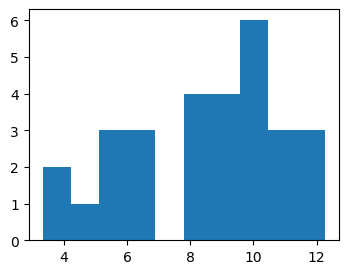

In [34]:
# Individuals with CH and MN, those are in class 1, (29, 24.5%), what is their time to incidence

CHMNclass1=predicted_class1_df[((predicted_class1_df['CHRS'] > 0)&(predicted_class1_df['MN'] == 1))][['gene1','gene2','VAF1','VAF2','age',
                                                                                         'sex','RDW','MCV','Hbconc','platelet',
                                                                                         'PDW','neutrophil','CH_score','CHRS',
                                                                                         'MN_type','time_to_MN']]
plt.figure(figsize=(4,3))
plt.hist(CHMNclass1['time_to_MN']);

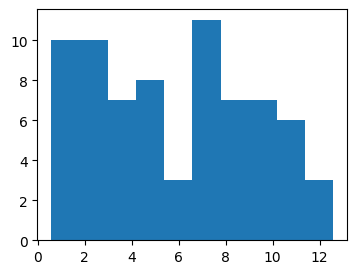

In [33]:
# Individuals with CH and MN, those are in class 2, (66%), what is their time to incidence

CHMNclass2=predicted_class2_df[((predicted_class2_df['CHRS'] > 0)&(predicted_class2_df['MN'] == 1))][['gene1','gene2','VAF1','VAF2','age',
                                                                                         'sex','RDW','MCV','Hbconc','platelet',
                                                                                         'PDW','neutrophil','CH_score','CHRS',
                                                                                         'MN_type','time_to_MN']]
plt.figure(figsize=(4,3))
plt.hist(CHMNclass2['time_to_MN']);

In [123]:
# Who are the 13 missed individuals??
predicted_class0_df[(predicted_class0_df['CHRS'] >0)&(predicted_class0_df['MN'] == 1)][['gene1','gene2','VAF1','VAF2','age',
                                                                                         'sex','RDW','MCV','Hbconc','platelet',
                                                                                         'PDW','neutrophil','CH_score','CHRS',
                                                                                         'MN_type','time_to_MN']]

,gene1,gene2,VAF1,VAF2,age,sex,RDW,MCV,Hbconc,platelet,PDW,neutrophil,CH_score,CHRS,MN_type,time_to_MN
197358,ASXL1,NaN,0.190,NaN,58.083333,1,13.60,90.50,14.60,244.0,17.10,3.90,4.0,8.0,C920,2.916667
362982,TET2,NaN,0.076,NaN,57.666667,0,12.46,87.91,13.20,194.8,16.61,4.80,4.0,8.0,C920,8.416667
304267,PPM1D,NaN,0.075,NaN,47.750000,1,13.34,97.75,15.39,212.3,16.47,3.54,4.0,8.0,D469,8.750000
208128,ASXL2,NaN,0.059,NaN,60.916667,0,12.45,91.81,13.24,356.2,16.29,5.46,4.0,8.0,D473,9.166667
210714,DNMT3A,NaN,0.147,NaN,58.416667,0,14.23,90.92,12.92,336.0,16.11,8.06,3.5,7.5,C920,4.500000
445752,DNMT3A,NaN,0.033,NaN,59.833333,1,13.10,92.70,15.20,180.0,16.80,5.20,3.5,7.5,C920,10.583333
254491,DNMT3A,NaN,0.309,NaN,47.916667,1,13.10,92.90,15.30,242.0,16.30,4.10,4.5,8.5,C920,3.083333
48935,DNMT3A,NaN,0.173,NaN,52.250000,0,12.56,93.89,15.06,239.8,16.66,4.45,3.5,7.5,D473,4.083333
102678,DNMT3A,NaN,0.079,NaN,46.000000,1,12.50,94.90,14.81,227.2,16.04,2.30,3.5,7.5,C920,6.833333
305218,ASXL1,IDH1,0.406,0.287,56.000000,1,13.55,86.51,17.06,251.5,15.76,3.57,7.5,11.5,C959,8.833333


In [125]:
# Check statistics of individuals with MN, in the predictions

# 1. Number of CH positive individuals with/ without MN
MN = (test_df['MN']==1).sum()
noMN = (test_df['MN']==0).sum()

print("Number of individuals with MN:",MN)
print("Number of individuals without MN:",noMN)

# How many CH positive individuals with MN were classified in positive classes?
MN_pred2 = (predicted_class2_df['MN'] == 1).sum()
MN_pred1 = (predicted_class1_df['MN'] == 1).sum()
MN_pred0 = (predicted_class0_df['MN'] == 1).sum()


print("Number of individuals with MN predicted in the classes 2,1,0:",MN_pred2, MN_pred1, MN_pred0)
print("Percentage of individuals with MN predicted in the positive classes:",
      round((MN_pred2+MN_pred1) * 100 / MN, 2), "%")

Number of individuals with MN: 335
Number of individuals without MN: 91981
Number of individuals with MN predicted in the classes 2,1,0: 170 94 71
Percentage of individuals with MN predicted in the positive classes: 78.81 %


In [136]:
### MN prediction stats ###
MN_pred2 = predicted_class2_df.loc[predicted_class2_df['MN'] == 1]
MN_pred1 = predicted_class1_df.loc[predicted_class1_df['MN'] == 1]
MN_pred0 = predicted_class0_df.loc[predicted_class0_df['MN'] == 1]

df=MN_pred2.copy()

# CHIP and CCUS
anemia = ((df['sex'] == 0) & (df['Hbconc'] < 12)) | ((df['sex'] == 1) & (df['Hbconc'] < 13))
neutropenia = df['neutrophil'] < 1.8
thrombocytopenia = df['platelet'] < 150

CH = df['CHRS'] > 0
cytopenia = (anemia | neutropenia | thrombocytopenia)

print('no CH:', df[~CH].shape[0])
print('CH:', df[CH].shape[0])
print('CHIP:', df[CH&(~cytopenia)].shape[0])
print('CCUS:', df[CH&cytopenia].shape[0])
print('Cytopenia:', df[cytopenia].shape[0])

# CHRS
hr=df['CHRS'] >= 12.5
ir=(df['CHRS'] >= 10)&(df['CHRS'] < 12.5)
lr=(df['CHRS'] > 0)&(df['CHRS'] < 10)

print('high-risk', df[hr].shape[0])
print('intermediate-risk', df[ir].shape[0])
print('low-risk', df[lr].shape[0])

no CH: 98
CH: 72
CHIP: 46
CCUS: 26
Cytopenia: 53
high-risk 20
intermediate-risk 30
low-risk 22


### cytopenia and cytoses classification ###

In [126]:
def classify_CH(df, cytopenia=True, cytoses=True, CHpos=True):
    # Define hematologic conditions
    anemia = ((df['sex'] == 0) & (df['Hbconc'] < 12)) | ((df['sex'] == 1) & (df['Hbconc'] < 13))
    neutropenia = df['neutrophil'] < 1.8
    thrombocytopenia = df['platelet'] < 150
    erythro = df['Hbconc'] >= 17
    neutro = df['neutrophil'] >= 6
    thrombo = df['platelet'] >= 450
    mono = df['monocyte'] >= 1
    eosin = df['eosinophil'] >= 0.5
    baso = df['basophil'] >= 0.3

    CH = df['CHRS'] > 0
    cytopenia_condition = (anemia | neutropenia | thrombocytopenia)
    cytoses_condition = (erythro | neutro | thrombo | mono | eosin | baso)

    # Choose between cytoses, cytopenia, and CHIP
    if cytopenia and cytoses:
        condition = cytopenia_condition & cytoses_condition
    elif cytoses and not cytopenia:
        condition = cytoses_condition & ~cytopenia_condition
    elif cytopenia and not cytoses:
        condition = cytopenia_condition & ~cytoses_condition
    else:
        condition = ~cytopenia_condition & ~cytoses_condition
        
    CHstatus = CH if CHpos else ~CH
    
    return df[CHstatus & condition]

def CHcytopenia(df):
    return classify_CH(df, cytopenia=True,cytoses=False, CHpos=True)

def CHcytoses(df):
    return classify_CH(df, cytopenia=False,cytoses=True, CHpos=True)    

def CHboth(df):
    return classify_CH(df, cytopenia=True,cytoses=True, CHpos=True)        

def CHIP(df):
    return classify_CH(df, cytopenia=False,cytoses=False, CHpos=True)

def cytopenia(df):
    return classify_CH(df, cytopenia=True,cytoses=False, CHpos=False)   
    
def cytoses(df):
    return classify_CH(df, cytopenia=False,cytoses=True, CHpos=False)   
    
def both(df):
    return classify_CH(df, cytopenia=True,cytoses=True, CHpos=False)    
    
def noBD(df):
    return classify_CH(df, cytopenia=False,cytoses=False, CHpos=False)    

# Print results
print("Number with CHcytopenia:", len(CHcytopenia(test_df)))
print("Number with CHcytoses:", len(CHcytoses(test_df)))
print("Number with CHboth:", len(CHboth(test_df)))
print("Number with CHIP:", len(CHIP(test_df)))    

Number with CHcytopenia: 371
Number with CHcytoses: 874
Number with CHboth: 87
Number with CHIP: 4555


In [127]:
print("cytopenia class 0:",len(cytopenia(predicted_class0_df)),"cytopenia class 1:",len(cytopenia(predicted_class1_df)),
      "cytopenia class 2:",len(cytopenia(predicted_class2_df)))
print("cytoses class 0:",len(cytoses(predicted_class0_df)),"cytoses class 1:",len(cytoses(predicted_class1_df)),
      "cytoses class 2:",len(cytoses(predicted_class2_df)))
print("both class 0:",len(both(predicted_class0_df)),"both class 1:",len(both(predicted_class1_df)),
      "both class 2:",len(both(predicted_class2_df)))
print("noBD class 0:",len(noBD(predicted_class0_df)),"noBD class 1:",len(noBD(predicted_class1_df)),
      "noBD class 2:",len(noBD(predicted_class2_df)))

cytopenia class 0: 2253 cytopenia class 1: 843 cytopenia class 2: 2187
cytoses class 0: 5585 cytoses class 1: 3977 cytoses class 2: 1942
both class 0: 224 both class 1: 92 both class 2: 576
noBD class 0: 39832 noBD class 1: 24208 noBD class 2: 4710


In [29]:
print("class 0:",len(predicted_class0_df),"class 1:",len(predicted_class1_df),
      "class 2:",len(predicted_class2_df))
print("class 0 CHIP:",len(CHIP(predicted_class0_df)),"class 1 CHIP:",len(CHIP(predicted_class1_df)),
      "class 2 CHIP:",len(CHIP(predicted_class2_df)))
print("class 0 CHcytopenia:",len(CHcytopenia(predicted_class0_df)),"class 1 CHcytopenia:",len(CHcytopenia(predicted_class1_df)),
      "class 2 CHcytopenia:",len(CHcytopenia(predicted_class2_df)))
print("class 0 CHcytoses:",len(CHcytoses(predicted_class0_df)),"class 1 CHcytoses:",len(CHcytoses(predicted_class1_df)),
      "class 2 CHcytoses:",len(CHcytoses(predicted_class2_df)))
print("class 0 CHboth:",len(CHboth(predicted_class0_df)),"class 1 CHboth:",len(CHboth(predicted_class1_df)),
      "class 2 CHboth:",len(CHboth(predicted_class2_df)))

class 0: 50098 class 1: 31851 class 2: 10367
class 0 CHIP: 1820 class 1 CHIP: 2283 class 2 CHIP: 452
class 0 CHcytopenia: 108 class 1 CHcytopenia: 61 class 2 CHcytopenia: 202
class 0 CHcytoses: 265 class 1 CHcytoses: 375 class 2 CHcytoses: 234
class 0 CHboth: 11 class 1 CHboth: 12 class 2 CHboth: 64


In [24]:
# 4. Among predicted positives, how many are high risk CHIP
hirisk_pred2 = (CHIP(predicted_class2_df)['CHRS'] >= 12.5).sum()
intermediate_pred2 = ((CHIP(predicted_class2_df)['CHRS'] >= 10)&(CHIP(predicted_class2_df)['CHRS'] < 12.5)).sum()
lowrisk_pred2 = ((CHIP(predicted_class2_df)['CHRS'] > 0)&(CHIP(predicted_class2_df)['CHRS'] < 10)).sum()

hirisk_pred1 = (CHIP(predicted_class1_df)['CHRS'] >= 12.5).sum()
intermediate_pred1 = ((CHIP(predicted_class1_df)['CHRS'] >= 10)&(CHIP(predicted_class1_df)['CHRS'] < 12.5)).sum()
lowrisk_pred1 = ((CHIP(predicted_class1_df)['CHRS'] > 0)&(CHIP(predicted_class1_df)['CHRS'] < 10)).sum()

hirisk_pred0 = (CHIP(predicted_class0_df)['CHRS'] >= 12.5).sum()
intermediate_pred0 = ((CHIP(predicted_class0_df)['CHRS'] >= 10)&(CHIP(predicted_class0_df)['CHRS'] < 12.5)).sum()
lowrisk_pred0 = ((CHIP(predicted_class0_df)['CHRS'] > 0)&(CHIP(predicted_class0_df)['CHRS'] < 10)).sum()

print("Actual high-risk CHIP among predicted positives with MN:", hirisk_pred2)
print("Actual intermediate-risk CHIP among predicted positives with MN:", intermediate_pred2)
print("Actual low-risk CHIP among predicted positives with MN:", lowrisk_pred2)

print("Actual high-risk CHIP among predicted positives without MN:", hirisk_pred1)
print("Actual intermediate-risk CHIP among predicted positives without MN:", intermediate_pred1)
print("Actual low-risk CHIP among predicted positives without MN:", lowrisk_pred1)

print("Actual hirisk-risk CHIP among predicted everyone else:", hirisk_pred0)
print("Actual intermediate-risk CHIP among predicted everyone else:", intermediate_pred0)
print("Actual low-risk CHIP among everyone else:", lowrisk_pred0)

Actual high-risk CHIP among predicted positives with MN: 9
Actual intermediate-risk CHIP among predicted positives with MN: 91
Actual low-risk CHIP among predicted positives with MN: 352
Actual high-risk CHIP among predicted positives without MN: 0
Actual intermediate-risk CHIP among predicted positives without MN: 111
Actual low-risk CHIP among predicted positives without MN: 2172
Actual hirisk-risk CHIP among predicted everyone else: 0
Actual intermediate-risk CHIP among predicted everyone else: 29
Actual low-risk CHIP among everyone else: 1791


In [26]:
# Who are the 29 individuals with CHIP that were classified safe
intermediate_pred0_df = CHIP(predicted_class0_df)[((CHIP(predicted_class0_df)['CHRS'] >= 10)
                                                   &(CHIP(predicted_class0_df)['CHRS'] < 12.5))][['gene1','gene2','VAF1','VAF2','age',
                                                                                         'sex','RDW','MCV','Hbconc','platelet',
                                                                                         'PDW','neutrophil','CH_score','CHRS',
                                                                                                 'time_to_MN','MN_type']]
intermediate_pred0_df

,gene1,gene2,VAF1,VAF2,age,sex,RDW,MCV,Hbconc,platelet,PDW,neutrophil,CH_score,CHRS,time_to_MN,MN_type
181425,TET2,JAK2,0.438000,0.207,47.750000,1,14.73,90.25,14.64,278.5,17.27,4.55,7.5,11.5,NaN,NaN
127524,IDH2,NaN,0.241000,NaN,55.833333,0,13.40,89.90,13.80,261.0,16.40,2.20,6.5,10.5,NaN,NaN
323668,TP53,DNMT3A,0.029000,0.059,42.250000,0,12.81,90.84,13.14,288.1,15.75,4.83,6.5,10.5,NaN,NaN
363320,DNMT3A,NaN,0.262000,NaN,49.833333,1,12.52,100.60,15.81,234.5,17.41,4.82,4.5,10.0,NaN,NaN
127584,TET2,DNMT3A,0.339000,0.236,53.000000,0,11.92,96.21,14.33,211.9,16.42,3.70,6.0,10.0,NaN,NaN
419412,PRPF8,DNMT3A,0.162000,0.210,50.750000,0,13.10,96.40,13.30,198.0,16.90,2.40,6.0,10.0,NaN,NaN
427057,DNMT3A,NaN,0.305000,NaN,53.083333,1,14.40,102.50,13.70,320.0,15.70,5.80,4.5,10.0,NaN,NaN
141137,TP53,TET2,0.054000,0.050,43.000000,0,16.70,84.30,12.60,271.0,16.00,3.30,6.5,12.0,NaN,NaN
126947,TP53,NaN,0.462000,NaN,55.583333,0,14.34,92.44,12.50,248.0,16.14,4.46,6.5,10.5,NaN,NaN
336862,BRCC3,DNMT3A,0.400000,0.223,61.333333,0,12.34,88.13,14.40,228.0,17.54,3.03,6.0,10.0,NaN,NaN


In [64]:
# 4. Among predicted positives, how many are high risk CCUS
hirisk_pred2 = (CHcytopenia(predicted_class2_df)['CHRS'] >= 12.5).sum()
intermediate_pred2 = ((CHcytopenia(predicted_class2_df)['CHRS'] >= 10)&(CHcytopenia(predicted_class2_df)['CHRS'] < 12.5)).sum()
lowrisk_pred2 = ((CHcytopenia(predicted_class2_df)['CHRS'] > 0)&(CHcytopenia(predicted_class2_df)['CHRS'] < 10)).sum()

hirisk_pred1 = (CHcytopenia(predicted_class1_df)['CHRS'] >= 12.5).sum()
intermediate_pred1 = ((CHcytopenia(predicted_class1_df)['CHRS'] >= 10)&(CHcytopenia(predicted_class1_df)['CHRS'] < 12.5)).sum()
lowrisk_pred1 = ((CHcytopenia(predicted_class1_df)['CHRS'] > 0)&(CHcytopenia(predicted_class1_df)['CHRS'] < 10)).sum()

hirisk_pred0 = (CHcytopenia(predicted_class0_df)['CHRS'] >= 12.5).sum()
intermediate_pred0 = ((CHcytopenia(predicted_class0_df)['CHRS'] >= 10)&(CHcytopenia(predicted_class0_df)['CHRS'] < 12.5)).sum()
lowrisk_pred0 = ((CHcytopenia(predicted_class0_df)['CHRS'] > 0)&(CHcytopenia(predicted_class0_df)['CHRS'] < 10)).sum()

print("Actual high-risk CCUS among predicted positives with MN:", hirisk_pred2)
print("Actual intermediate-risk CCUS among predicted positives with MN:", intermediate_pred2)
print("Actual low-risk CCUS among predicted positives with MN:", lowrisk_pred2)

print("Actual high-risk CCUS among predicted positives without MN:", hirisk_pred1)
print("Actual intermediate-risk CCUS among predicted positives without MN:", intermediate_pred1)
print("Actual low-risk CCUS among predicted positives without MN:", lowrisk_pred1)

print("Actual hirisk-risk CCUS among predicted everyone else:", hirisk_pred0)
print("Actual intermediate-risk CCUS among predicted everyone else:", intermediate_pred0)
print("Actual low-risk CCUS among everyone else:", lowrisk_pred0)

Actual high-risk CCUS among predicted positives with MN: 11
Actual intermediate-risk CCUS among predicted positives with MN: 73
Actual low-risk CCUS among predicted positives with MN: 109
Actual high-risk CCUS among predicted positives without MN: 0
Actual intermediate-risk CCUS among predicted positives without MN: 10
Actual low-risk CCUS among predicted positives without MN: 61
Actual hirisk-risk CCUS among predicted everyone else: 0
Actual intermediate-risk CCUS among predicted everyone else: 7
Actual low-risk CCUS among everyone else: 79


In [65]:
# 4. Among predicted positives, how many are high risk CCUS
hirisk_pred2 = (CHcytoses(predicted_class2_df)['CHRS'] >= 12.5).sum()
intermediate_pred2 = ((CHcytoses(predicted_class2_df)['CHRS'] >= 10)&(CHcytoses(predicted_class2_df)['CHRS'] < 12.5)).sum()
lowrisk_pred2 = ((CHcytoses(predicted_class2_df)['CHRS'] > 0)&(CHcytoses(predicted_class2_df)['CHRS'] < 10)).sum()

hirisk_pred1 = (CHcytoses(predicted_class1_df)['CHRS'] >= 12.5).sum()
intermediate_pred1 = ((CHcytoses(predicted_class1_df)['CHRS'] >= 10)&(CHcytoses(predicted_class1_df)['CHRS'] < 12.5)).sum()
lowrisk_pred1 = ((CHcytoses(predicted_class1_df)['CHRS'] > 0)&(CHcytoses(predicted_class1_df)['CHRS'] < 10)).sum()

hirisk_pred0 = (CHcytoses(predicted_class0_df)['CHRS'] >= 12.5).sum()
intermediate_pred0 = ((CHcytoses(predicted_class0_df)['CHRS'] >= 10)&(CHcytoses(predicted_class0_df)['CHRS'] < 12.5)).sum()
lowrisk_pred0 = ((CHcytoses(predicted_class0_df)['CHRS'] > 0)&(CHcytoses(predicted_class0_df)['CHRS'] < 10)).sum()

print("Actual high-risk CHcytoses among predicted positives with MN:", hirisk_pred2)
print("Actual intermediate-risk CHcytoses among predicted positives with MN:", intermediate_pred2)
print("Actual low-risk CHcytoses among predicted positives with MN:", lowrisk_pred2)

print("Actual high-risk CHcytoses among predicted positives without MN:", hirisk_pred1)
print("Actual intermediate-risk CHcytoses among predicted positives without MN:", intermediate_pred1)
print("Actual low-risk CHcytoses among predicted positives without MN:", lowrisk_pred1)

print("Actual hirisk-risk CHcytoses among predicted everyone else:", hirisk_pred0)
print("Actual intermediate-risk CHcytoses among predicted everyone else:", intermediate_pred0)
print("Actual low-risk CHcytoses among everyone else:", lowrisk_pred0)

Actual high-risk CHcytoses among predicted positives with MN: 8
Actual intermediate-risk CHcytoses among predicted positives with MN: 57
Actual low-risk CHcytoses among predicted positives with MN: 153
Actual high-risk CHcytoses among predicted positives without MN: 0
Actual intermediate-risk CHcytoses among predicted positives without MN: 23
Actual low-risk CHcytoses among predicted positives without MN: 420
Actual hirisk-risk CHcytoses among predicted everyone else: 0
Actual intermediate-risk CHcytoses among predicted everyone else: 6
Actual low-risk CHcytoses among everyone else: 232


In [66]:
# 4. Among predicted positives, how many are high risk CCUS
hirisk_pred2 = (CHboth(predicted_class2_df)['CHRS'] >= 12.5).sum()
intermediate_pred2 = ((CHboth(predicted_class2_df)['CHRS'] >= 10)&(CHboth(predicted_class2_df)['CHRS'] < 12.5)).sum()
lowrisk_pred2 = ((CHboth(predicted_class2_df)['CHRS'] > 0)&(CHboth(predicted_class2_df)['CHRS'] < 10)).sum()

hirisk_pred1 = (CHboth(predicted_class1_df)['CHRS'] >= 12.5).sum()
intermediate_pred1 = ((CHboth(predicted_class1_df)['CHRS'] >= 10)&(CHboth(predicted_class1_df)['CHRS'] < 12.5)).sum()
lowrisk_pred1 = ((CHboth(predicted_class1_df)['CHRS'] > 0)&(CHboth(predicted_class1_df)['CHRS'] < 10)).sum()

hirisk_pred0 = (CHboth(predicted_class0_df)['CHRS'] >= 12.5).sum()
intermediate_pred0 = ((CHboth(predicted_class0_df)['CHRS'] >= 10)&(CHboth(predicted_class0_df)['CHRS'] < 12.5)).sum()
lowrisk_pred0 = ((CHboth(predicted_class0_df)['CHRS'] > 0)&(CHboth(predicted_class0_df)['CHRS'] < 10)).sum()

print("Actual high-risk CHboth among predicted positives with MN:", hirisk_pred2)
print("Actual intermediate-risk CHboth among predicted positives with MN:", intermediate_pred2)
print("Actual low-risk CHboth among predicted positives with MN:", lowrisk_pred2)

print("Actual high-risk CHboth among predicted positives without MN:", hirisk_pred1)
print("Actual intermediate-risk CHboth among predicted positives without MN:", intermediate_pred1)
print("Actual low-risk CHboth among predicted positives without MN:", lowrisk_pred1)

print("Actual hirisk-risk CHboth among predicted everyone else:", hirisk_pred0)
print("Actual intermediate-risk CHboth among predicted everyone else:", intermediate_pred0)
print("Actual low-risk CHboth among everyone else:", lowrisk_pred0)

Actual high-risk CHboth among predicted positives with MN: 13
Actual intermediate-risk CHboth among predicted positives with MN: 18
Actual low-risk CHboth among predicted positives with MN: 27
Actual high-risk CHboth among predicted positives without MN: 0
Actual intermediate-risk CHboth among predicted positives without MN: 2
Actual low-risk CHboth among predicted positives without MN: 7
Actual hirisk-risk CHboth among predicted everyone else: 0
Actual intermediate-risk CHboth among predicted everyone else: 4
Actual low-risk CHboth among everyone else: 11


## HMDR ##

In [1]:
# Load the saved model
import pickle
with open("models/3class_BRF_giantplt_ASH_latest.pkl", "rb") as f:
    loaded_package = pickle.load(f)

loaded_model = loaded_package['model']
loaded_features = loaded_package['features']
loaded_thresholds = loaded_package['optimal_thresholds']
loaded_classes = loaded_package['classes']
print(loaded_classes)

[0.0, 1.0, 2.0]


In [4]:
# Test on validation set 

df_HMDR=pd.read_csv("/Users/riyanandi/Desktop/HMDR/HMDR_testdata_3class_new_2.csv",index_col=0)
df_HMDR.head()

,Dfci.Mrn,ALLELEFRACTIONNBR,HARMONIZEDHUGOGENENM,CH,mutnum,score,Diagnosis Date,basophil,eosinophil,lymphocyte,...,plateletcrit,reticulocyte,sex,Pt Date Of Birth,Date of Death,MN,MN_type,MN_date,age,CHRS
0,114485,0.2012,DNMT3A,0.0,1,3.5,2018.416667,NaN,0.234,1.000,...,0.17775,0.033000,0,1926.416667,2018.916667,0.0,NaN,NaN,92.000000,10.0
1,121238,0.5455,CUX1,0.0,0,0.0,2016.250000,NaN,0.098,1.088,...,0.11352,0.039000,1,1928.000000,2016.583333,0.0,NaN,NaN,88.250000,0.0
2,129759,0.5042,TET2,0.0,0,0.0,2015.083333,0.02,0.050,0.720,...,0.28912,0.132700,0,1966.166667,NaN,0.0,NaN,NaN,48.916667,0.0
3,130239,0.9000,PAX5,0.0,0,0.0,2014.833333,0.04,0.140,1.210,...,0.15030,0.068700,0,1983.666667,NaN,0.0,NaN,NaN,31.166667,0.0
4,131477,0.5103,KIT,0.0,0,0.0,2018.250000,NaN,0.068,1.074,...,0.02813,0.062478,0,1975.416667,2020.333333,0.0,NaN,NaN,42.833333,0.0


### HMDR cohort stats ###

In [5]:
print(len(df_HMDR))
print(df_HMDR['age'].mean(),df_HMDR['age'].std())
print((df_HMDR['sex']==1).sum(),(df_HMDR['sex']==0).sum())
print((df_HMDR['MN']==0).sum(),(df_HMDR['MN']==1).sum())

2233
63.28735632183909 16.255866802721858
989 1244
2213 20


In [6]:
print((df_HMDR['score']<=4).sum(),(df_HMDR['score']>4).sum())

1798 435


In [62]:
print((df_HMDR['CHRS']==0).sum(),((df_HMDR['CHRS']>0)&(df_HMDR['CHRS']<=9.5)).sum(),
      ((df_HMDR['CHRS']>9.5)&(df_HMDR['CHRS']<12.5)).sum(),(df_HMDR['CHRS']>=12.5).sum())

1425 259 373 176


In [61]:
# Define conditions

anemia = ((df_HMDR['sex'] == 0) & (df_HMDR['Hbconc'] < 12)) | ((df_HMDR['sex'] == 1) & (df_HMDR['Hbconc'] < 13))
neutropenia = df_HMDR['neutrophil'] < 1.8
thrombocytopenia = df_HMDR['platelet'] < 150
erythro = df_HMDR['Hbconc'] >= 17
neutro = df_HMDR['neutrophil'] >= 6
thrombo = df_HMDR['platelet'] >= 450
mono = df_HMDR['monocyte'] >= 1
eosin = df_HMDR['eosinophil'] >=0.5
baso=df_HMDR['basophil']>=0.3

# CH
CH=df_HMDR['CHRS']>0

# Cytopenia
cytopenia = anemia | neutropenia | thrombocytopenia

# Cytoses
cytoses= erythro| neutro| thrombo| mono| eosin| baso

# CCUS
CCUS = df_HMDR[CH&cytopenia].shape[0]

# cytoses +CH
cytoCH= df_HMDR[CH&cytoses].shape[0]

# CHIP
CHIP = df_HMDR[CH&(~cytopenia)&(~cytoses)].shape[0]

# cytoses+cytopenia+CH
bothCH= df_HMDR[CH&cytopenia&cytoses].shape[0]

# Print results
print("Number with CH:", CH.sum())
print("Number with CCUS:", CCUS)
print("Number with Cytoses:", cytoCH)
print("Number with CHIP:", CHIP)
print("Number with CH, cytopenia and cytoses:", bothCH)

Number with CH: 808
Number with CCUS: 602
Number with Cytoses: 278
Number with CHIP: 116
Number with CH, cytopenia and cytoses: 188


In [9]:
# Define conditions

anemia = ((df_HMDR['sex'] == 0) & (df_HMDR['Hbconc'] < 12)) | ((df_HMDR['sex'] == 1) & (df_HMDR['Hbconc'] < 13))
neutropenia = df_HMDR['neutrophil'] < 1.8
thrombocytopenia = df_HMDR['platelet'] < 150
erythro = df_HMDR['Hbconc'] >= 17
neutro = df_HMDR['neutrophil'] >= 6
thrombo = df_HMDR['platelet'] >= 450
mono = df_HMDR['monocyte'] >= 1
eosin = df_HMDR['eosinophil'] >=0.5
baso=df_HMDR['basophil']>=0.3

# Cytopenia
cytopenia = anemia | neutropenia | thrombocytopenia

# Cytoses
cytoses= erythro| neutro| thrombo| mono| eosin| baso

# CCUS
CCUS = df_HMDR[cytopenia].shape[0]

# cytoses 
cyto= df_HMDR[cytoses].shape[0]

# CHIP
noBD = df_HMDR[(~cytopenia)&(~cytoses)].shape[0]

# cytoses+cytopenia+CH
both= df_HMDR[cytopenia&cytoses].shape[0]

# Print results
print("Number with Cytopenia:", CCUS)
print("Number with Cytoses:", cyto)
print("Number with noBD:", noBD)
print("Number with cytopenia and cytoses:", both)

Number with Cytopenia: 1420
Number with Cytoses: 867
Number with noBD: 402
Number with cytopenia and cytoses: 456


In [10]:
print(((df_HMDR['CHRS'] >= 12.5)&(df_HMDR['MN']==0)).sum())
print(((df_HMDR['CHRS'] >= 10)&(df_HMDR['CHRS'] < 12.5)&(df_HMDR['MN']==0)).sum())
print(((df_HMDR['CHRS'] > 0)&(df_HMDR['CHRS'] < 10)&(df_HMDR['MN']==0)).sum())
print(((df_HMDR['CHRS'] == 0)&(df_HMDR['MN']==0)).sum())


print(((df_HMDR['CHRS'] >= 12.5)&(df_HMDR['MN']==1)).sum())
print(((df_HMDR['CHRS'] >= 10)&(df_HMDR['CHRS'] < 12.5)&(df_HMDR['MN']==1)).sum())
print(((df_HMDR['CHRS'] > 0)&(df_HMDR['CHRS'] < 10)&(df_HMDR['MN']==1)).sum())
print(((df_HMDR['CHRS'] == 0)&(df_HMDR['MN']==1)).sum())

164
369
257
1423
12
4
2
2


In [11]:
def stats(df,feature):
    q1 =df[feature].describe()['25%']
    q2 = df[feature].describe()['50%']
    q3 = df[feature].describe()['75%']

    return q1,q2,q3

features=['RBC','Hbconc', 'MCV', 'RDW', 'platelet','plateletcrit','lymphocyte','monocyte', 'neutrophil', 
              'eosinophil', 'reticulocyte','age']

print('feature, Q1, median, Q2:')
for i in features:
    q1,q2,q3 = stats(df_HMDR,i)
    print(i,q1,q2,q3)

feature, Q1, median, Q2:
RBC 3.36 4.06 4.65
Hbconc 10.4 12.4 14.0
MCV 87.6 91.9 97.5
RDW 13.2 14.2 16.0
platelet 130.0 199.0 271.0
plateletcrit 0.1197 0.1776 0.24252
lymphocyte 0.988 1.35 1.96
monocyte 0.38 0.516 0.7
neutrophil 2.558 3.84 5.440000000000001
eosinophil 0.0799999999999998 0.14 0.3
reticulocyte 0.0500000000000682 0.0625 0.078200000000038
age 53.0 65.75 75.33333333333326


In [12]:
df_HMDR['giant_plt'].value_counts()

giant_plt
0.0    2200
1.0      33
Name: count, dtype: int64

In [13]:
positive = df_HMDR.loc[df_HMDR['CH']==2]
equivocal = df_HMDR.loc[df_HMDR['CH']==1]
negative = df_HMDR.loc[df_HMDR['CH']==0]
stats(positive,'age'),stats(equivocal,'age'),stats(negative,'age')

((63.33333333333337, 68.79166666666663, 73.99999999999994),
 (69.33333333333326, 76.75, 82.75),
 (49.6041666666668, 62.58333333333326, 72.16666666666652))

In [14]:
print((positive['sex']==1).sum(),(positive['sex']==0).sum())
print((equivocal['sex']==1).sum(),(equivocal['sex']==0).sum())
print((negative['sex']==1).sum(),(negative['sex']==0).sum())

12 6
214 203
763 1035


In [15]:
# CHIP
# Define conditions
anemia = ((positive['sex'] == 0) & (positive['Hbconc'] < 12)) | ((positive['sex'] == 1) & (positive['Hbconc'] < 13))
neutropenia = positive['neutrophil'] < 1.8
thrombocytopenia =positive['platelet'] < 150
CH = positive['CHRS']>0
# Cytopenia
cytopenia = anemia | neutropenia | thrombocytopenia
print(positive[CH].shape[0],positive[CH&cytopenia].shape[0])

18 17


In [16]:
# CHIP
# Define conditions
anemia = ((equivocal['sex'] == 0) & (equivocal['Hbconc'] < 12)) | ((equivocal['sex'] == 1) & (equivocal['Hbconc'] < 13))
neutropenia = equivocal['neutrophil'] < 1.8
thrombocytopenia =equivocal['platelet'] < 150
CH = equivocal['CHRS']>0
# Cytopenia
cytopenia = anemia | neutropenia | thrombocytopenia
print(equivocal[CH].shape[0],equivocal[CH&cytopenia].shape[0])

417 342


In [17]:
# CHIP
# Define conditions
anemia = ((negative['sex'] == 0) & (negative['Hbconc'] < 12)) | ((negative['sex'] == 1) & (negative['Hbconc'] < 13))
neutropenia = negative['neutrophil'] < 1.8
thrombocytopenia =negative['platelet'] < 150
CH = negative['CHRS']>0
# Cytopenia
cytopenia = anemia | neutropenia | thrombocytopenia
print(negative[CH].shape[0],negative[CH&cytopenia].shape[0])

373 243


### Prediction ###

In [18]:
# On HMDR

X_HMDR=df_HMDR.drop(columns=['Dfci.Mrn','Diagnosis Date','basophil','MPV','MCHbconc','score','sex','MN','Pt Date Of Birth','MN_type',
                             'MN_date','CH','CHRS'])
y_HMDR=df_HMDR[['CH']]
X_HMDR.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2233 entries, 0 to 2232
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ALLELEFRACTIONNBR     2233 non-null   float64
 1   HARMONIZEDHUGOGENENM  2233 non-null   object 
 2   mutnum                2233 non-null   int64  
 3   eosinophil            2233 non-null   float64
 4   lymphocyte            2233 non-null   float64
 5   monocyte              2233 non-null   float64
 6   neutrophil            2233 non-null   float64
 7   MCV                   2233 non-null   float64
 8   RDW                   2233 non-null   float64
 9   RBC                   2233 non-null   float64
 10  Hbconc                2233 non-null   float64
 11  platelet              2233 non-null   float64
 12  MCHb                  2220 non-null   float64
 13  giant_plt             2233 non-null   float64
 14  plateletcrit          2233 non-null   float64
 15  reticulocyte          2233

In [19]:
features_kept=[ 'RBC','Hbconc', 'MCV', 'RDW', 'platelet', 'plateletcrit', 'lymphocyte',
       'monocyte', 'neutrophil', 'eosinophil', 'reticulocyte', 'age','giant_plt']
X_reordered=X_HMDR[features_kept]
X_reordered.columns

Index(['RBC', 'Hbconc', 'MCV', 'RDW', 'platelet', 'plateletcrit', 'lymphocyte',
       'monocyte', 'neutrophil', 'eosinophil', 'reticulocyte', 'age',
       'giant_plt'],
      dtype='object')

In [20]:
y_HMDR.value_counts()

CH 
0.0    1798
1.0     417
2.0      18
Name: count, dtype: int64

In [49]:
# Get prediction with threshold 
y_pred_proba=loaded_model.predict_proba(X_reordered)
threshold_array=np.array([loaded_thresholds[c] for c in loaded_classes])

y_pred_custom=[]

for prob_vector in y_pred_proba:
    passing_classes=np.where(prob_vector>=threshold_array)[0]
    if passing_classes.size>0:
        passing_margin=prob_vector[passing_classes]-threshold_array[passing_classes]
        max_passing_index=np.argmax(passing_margin)
        chosen_class_index=passing_classes[max_passing_index]
        chosen_class=loaded_classes[chosen_class_index]
    else:
        chosen_class_index=np.argmax(prob_vector)
        chosen_class=loaded_classes[chosen_class_index]
    
    y_pred_custom.append(chosen_class)

y_pred_custom = np.array(y_pred_custom)

#  Indices where the model predicted "CH positive with MN" (label 2)
mask_2 = (y_pred_custom == 2)
n_rows_2 = np.where(mask_2)[0]

#  Indices where the model predicted "CH positive without MN" (label 1)
mask_1 = (y_pred_custom == 1)
n_rows_1 = np.where(mask_1)[0]

#  Indices where the model predicted "Everyone else" (label 0)
mask_0 = (y_pred_custom == 0)
n_rows_0 = np.where(mask_0)[0]

# Subset of X_test corresponding to predicted positive
predicted_class2_df = df_HMDR.iloc[n_rows_2]
predicted_class1_df = df_HMDR.iloc[n_rows_1]
predicted_class0_df = df_HMDR.iloc[n_rows_0]

# Print the stats 
print("Number of people predicted in class 2:",len(predicted_class2_df),len(predicted_class2_df)*100/len(y_pred_custom))
print("Number of people predicted in class 1:",len(predicted_class1_df),len(predicted_class1_df)*100/len(y_pred_custom))
print("Number of people predicted in class 0:",len(predicted_class0_df),len(predicted_class0_df)*100/len(y_pred_custom))

Number of people predicted in class 2: 1554 69.59247648902821
Number of people predicted in class 1: 207 9.270040304523063
Number of people predicted in class 0: 472 21.137483206448724


In [62]:
# Get prediction with default threshold
y_pred_custom=loaded_model.predict(X_reordered)

#  Indices where the model predicted "CH positive with MN" (label 2)
mask_2 = (y_pred_custom == 2)
n_rows_2 = np.where(mask_2)[0]

#  Indices where the model predicted "CH positive without MN" (label 1)
mask_1 = (y_pred_custom == 1)
n_rows_1 = np.where(mask_1)[0]

#  Indices where the model predicted "Everyone else" (label 0)
mask_0 = (y_pred_custom == 0)
n_rows_0 = np.where(mask_0)[0]

# Subset of X_test corresponding to predicted positive
predicted_class2_df = df_HMDR.iloc[n_rows_2]
predicted_class1_df = df_HMDR.iloc[n_rows_1]
predicted_class0_df = df_HMDR.iloc[n_rows_0]

# Print the stats 
print("Number of people predicted in class 2:",len(predicted_class2_df),len(predicted_class2_df)*100/len(y_pred_custom))
print("Number of people predicted in class 1:",len(predicted_class1_df),len(predicted_class1_df)*100/len(y_pred_custom))
print("Number of people predicted in class 0:",len(predicted_class0_df),len(predicted_class0_df)*100/len(y_pred_custom))

Number of people predicted in class 2: 1431 64.08419167039857
Number of people predicted in class 1: 299 13.390058217644425
Number of people predicted in class 0: 503 22.52575011195701


In [67]:
predicted_class0_df[(predicted_class0_df['score']<4)&(predicted_class0_df['MN']==0)]
predicted_class2_df[predicted_class2_df['Dfci.Mrn']==303880][features_kept]
#predicted_class2_df[predicted_class2_df['Dfci.Mrn']==303880][['sex','Diagnosis Date','score','CHRS','MN_type','MN_date']]
#predicted_class1_df[predicted_class1_df['Dfci.Mrn']==187942][features_kept]
#predicted_class1_df[predicted_class1_df['Dfci.Mrn']==187942][['sex','Diagnosis Date','score','CHRS','MN_type','MN_date']]
#predicted_class0_df[predicted_class0_df['Dfci.Mrn']==180149][features_kept]
#predicted_class0_df[predicted_class0_df['Dfci.Mrn']==180149][['sex','Diagnosis Date','score','CHRS','MN_type','MN_date']]

,RBC,Hbconc,MCV,RDW,platelet,plateletcrit,lymphocyte,monocyte,neutrophil,eosinophil,reticulocyte,age,giant_plt
126,2.76,8.9,94.2,18.4,69.0,0.097514,0.808,0.574,3.254,0.07,0.069348,60.5,1.0


### AUC and threshold ###


--- Plotting ROC-AUC Curve ---


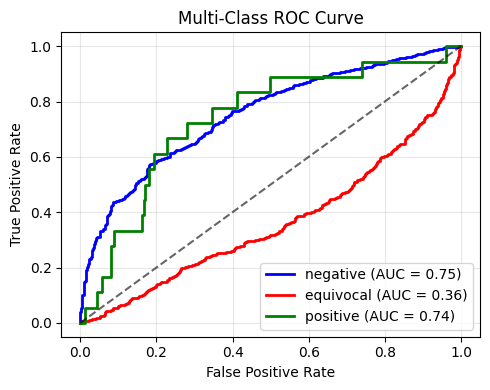

In [22]:
accuracy = accuracy_score(y_HMDR, y_pred_custom)
#print(f"\nAccuracy Score (Optimal OvR Thresholds): {accuracy:.4f}")
#print("\nClassification Report (Optimal OvR Thresholds):")
#print(classification_report(y_HMDR, y_pred_custom))

n_classes=len(loaded_classes)
class_names = {
    0: "negative",
    1: "equivocal",
    2: "positive"
}
#print(n_classes,loaded_classes)
# --- 5b. Plot ROC-AUC Curve (Uses y_proba_test) ---
print("\n--- Plotting ROC-AUC Curve ---")
y_test_bin = label_binarize(y_HMDR, classes=loaded_classes)
colors = ['blue', 'red', 'green', 'brown']

plt.figure(figsize=(5, 4))
for i in range(n_classes):
    fpr, tpr, thresholds = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i % len(colors)], lw=2, label=f'{class_names[loaded_classes[i]]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='black', alpha=0.6)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve")
plt.legend(loc="lower right",fontsize=10)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figures/roc_auc_hmdr.png", dpi=300, bbox_inches='tight')
plt.show()

### Confusion Matrix and Accuracy ###

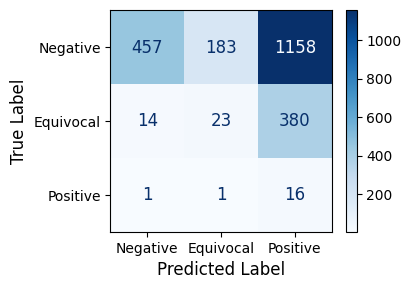

In [23]:
cmap = sns.color_palette("Blues", as_cmap=True)
cm = confusion_matrix(y_HMDR, y_pred_custom)
# Define your custom class labels
class_names = ["Negative", "Equivocal", "Positive"]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

plt.figure(figsize=(4, 3))
ax = plt.gca()
disp.plot(cmap=cmap, ax=ax, values_format='d', text_kw={"fontsize": 12})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)

plt.tight_layout()
plt.savefig("figures/confusion_matrix_hmdr.png", dpi=300, bbox_inches='tight')
plt.show()

### Prediction class feature characteristics ###

In [58]:
def stats(df,feature):
    q1 =df[feature].describe()['25%']
    q2 = df[feature].describe()['50%']
    q3 = df[feature].describe()['75%']

    return q1,q2,q3

print('feature, Q1, median, Q2:')
for i in loaded_features:
    q1,q2,q3 = stats(predicted_class2_df,i)
    print(i,q1,q2,q3)

feature, Q1, median, Q2:
RBC 3.09 3.69 4.31
Hbconc 9.6 11.4 13.0
MCV 87.6 93.1 99.3
RDW 13.7 15.0 17.0
platelet 111.0 177.0 268.75
plateletcrit 0.10626 0.15825 0.2415
lymphocyte 0.89 1.213 1.73
monocyte 0.3605 0.52 0.74
neutrophil 2.390000000000001 3.7010000000000023 5.42
eosinophil 0.0699999999999999 0.14 0.3
reticulocyte 0.04955500000008325 0.06282000000004465 0.08189499999997447
age 61.10416666666663 70.25 77.97916666666669
giant_plt 0.0 0.0 0.0


In [57]:
predicted_class2_df['sex'].value_counts()

sex
0    845
1    709
Name: count, dtype: int64

In [56]:
# Define conditions
df=predicted_class2_df
anemia = ((df['sex'] == 0) & (df['Hbconc'] < 12)) | ((df['sex'] == 1) & (df['Hbconc'] < 13))
neutropenia = df['neutrophil'] < 1.8
thrombocytopenia = df['platelet'] < 150
erythro = df['Hbconc'] >= 17
neutro = df['neutrophil'] >= 6
thrombo = df['platelet'] >= 450
mono = df['monocyte'] >= 1
eosin = df['eosinophil'] >=0.5
baso= df['basophil']>=0.3

# CH
CH= df['CHRS']>0

# Cytopenia
cytopenia = anemia | neutropenia | thrombocytopenia

# Cytoses
cytoses= erythro| neutro| thrombo| mono| eosin| baso

# CCUS
CCUS = df[CH&cytopenia].shape[0]

# cytoses +CH
cytoCH= df[CH&cytoses].shape[0]

# CHIP
#CHIP = df[CH&(~cytopenia)&(~cytoses)].shape[0]
CHIP = df[CH&(~cytopenia)].shape[0]

# cytoses+cytopenia+CH
bothCH= df[CH&cytopenia&cytoses].shape[0]

# Print results
print("Number with CH:", CH.sum())
print("Number with CCUS:", CCUS)
print("Number with Cytoses:", cytoCH)
print("Number with CHIP:", CHIP)
print("Number with CH, cytopenia and cytoses:", bothCH)

Number with CH: 685
Number with CCUS: 580
Number with Cytoses: 239
Number with CHIP: 105
Number with CH, cytopenia and cytoses: 182


In [55]:
# 1. Actual number of high-risk individuals in the training set
df=predicted_class2_df
hirisk_true = (df['CHRS'] >= 12.5).sum()
intermediate_true = ((df['CHRS'] >= 10)&(df['CHRS'] < 12.5)).sum()
lowrisk_true = ((df['CHRS'] > 0)&(df['CHRS'] < 10)).sum()
norisk_true = (df['CHRS'] == 0).sum()

hirisk_true,intermediate_true,lowrisk_true,norisk_true

(176, 350, 159, 869)

### Prediction class analysis ###

In [28]:
# Check CHRS statistics of predicted labels 

# 1. Actual number of high-risk individuals in the test set
hirisk_true = (df_HMDR['CHRS'] >= 12.5).sum()
intermediate_true = ((df_HMDR['CHRS'] >= 10)&(df_HMDR['CHRS'] < 12.5)).sum()
lowrisk_true = ((df_HMDR['CHRS'] > 0)&(df_HMDR['CHRS'] < 10)).sum()
norisk_true = (df_HMDR['CHRS'] == 0).sum()
                      
#  Indices where the model predicted "CH positive with MN" (label 2)
mask_2 = (y_pred_custom == 2)
n_rows_2 = np.where(mask_2)[0]

#  Indices where the model predicted "CH positive without MN" (label 1)
mask_1 = (y_pred_custom == 1)
n_rows_1 = np.where(mask_1)[0]

#  Indices where the model predicted "Everyone else" (label 0)
mask_0 = (y_pred_custom == 0)
n_rows_0 = np.where(mask_0)[0]

# 3. Subset of X_test corresponding to predicted positive
predicted_class2_df = df_HMDR.iloc[n_rows_2]
predicted_class1_df = df_HMDR.iloc[n_rows_1]
predicted_class0_df = df_HMDR.iloc[n_rows_0]

# 4. Among predicted positives, how many are high risk
hirisk_pred2 = (predicted_class2_df['CHRS'] >= 12.5).sum()
intermediate_pred2 = ((predicted_class2_df['CHRS'] >= 10)&(predicted_class2_df['CHRS'] < 12.5)).sum()
lowrisk_pred2 = ((predicted_class2_df['CHRS'] > 0)&(predicted_class2_df['CHRS'] < 10)).sum()
norisk_pred2 = (predicted_class2_df['CHRS'] == 0).sum()

hirisk_pred1 = (predicted_class1_df['CHRS'] >= 12.5).sum()
intermediate_pred1 = ((predicted_class1_df['CHRS'] >= 10)&(predicted_class1_df['CHRS'] < 12.5)).sum()
lowrisk_pred1 = ((predicted_class1_df['CHRS'] > 0)&(predicted_class1_df['CHRS'] < 10)).sum()
norisk_pred1 = (predicted_class1_df['CHRS'] == 0).sum()

hirisk_pred0 = (predicted_class0_df['CHRS'] >= 12.5).sum()
intermediate_pred0 = ((predicted_class0_df['CHRS'] >= 10)&(predicted_class0_df['CHRS'] < 12.5)).sum()
lowrisk_pred0 = ((predicted_class0_df['CHRS'] > 0)&(predicted_class0_df['CHRS'] < 10)).sum()
norisk_pred0 = (predicted_class0_df['CHRS'] == 0).sum()

# 5. Print the results
print("Actual high-risk count:", hirisk_true)
print("Actual intermediate-risk count:", intermediate_true)
print("Actual low-risk count:", lowrisk_true)
print("Actual no-risk count:", norisk_true)

print("Actual high-risk count among predicted positives with MN:", hirisk_pred2)
print("Actual intermediate-risk count among predicted positives with MN:", intermediate_pred2)
print("Actual low-risk count among predicted positives with MN:", lowrisk_pred2)
print("Actual norisk-risk count among predicted positives with MN:", norisk_pred2)

print("Actual high-risk count among predicted positives without MN:", hirisk_pred1)
print("Actual intermediate-risk count among predicted positives without MN:", intermediate_pred1)
print("Actual low-risk count among predicted positives without MN:", lowrisk_pred1)
print("Actual norisk-risk count among predicted positives without MN:", norisk_pred1)

print("Actual high-risk count among everyone else:", hirisk_pred0)
print("Actual intermediate-risk count among predicted everyone else:", intermediate_pred0)
print("Actual low-risk count among everyone else:", lowrisk_pred0)
print("Actual norisk-risk count among everyone else:", norisk_pred0)


print("Percentage of actual high-risk correctly predicted:",round(hirisk_pred2 * 100 / hirisk_true, 2), "%")
print("Percentage of actual intermediate-risk predicted in positives classes 1 or 2:",round((intermediate_pred2+intermediate_pred1) * 100 / intermediate_true, 2), "%")
print("Percentage of actual intermediate-risk predicted in negative class:",round(intermediate_pred0 * 100 / intermediate_true, 2), "%")

Actual high-risk count: 176
Actual intermediate-risk count: 373
Actual low-risk count: 259
Actual no-risk count: 1425
Actual high-risk count among predicted positives with MN: 176
Actual intermediate-risk count among predicted positives with MN: 350
Actual low-risk count among predicted positives with MN: 159
Actual norisk-risk count among predicted positives with MN: 869
Actual high-risk count among predicted positives without MN: 0
Actual intermediate-risk count among predicted positives without MN: 13
Actual low-risk count among predicted positives without MN: 64
Actual norisk-risk count among predicted positives without MN: 130
Actual high-risk count among everyone else: 0
Actual intermediate-risk count among predicted everyone else: 10
Actual low-risk count among everyone else: 36
Actual norisk-risk count among everyone else: 426
Percentage of actual high-risk correctly predicted: 100.0 %
Percentage of actual intermediate-risk predicted in positives classes 1 or 2: 97.32 %
Percent

In [29]:
predicted_class1_df[(predicted_class1_df['CHRS'] >= 12.5)][['age','ALLELEFRACTIONNBR','HARMONIZEDHUGOGENENM',
                                                                                         'Diagnosis Date','sex','RDW','MCV','Hbconc',
                                                                                         'platelet','neutrophil','score','CHRS','MN_type','MN_date']]

,age,ALLELEFRACTIONNBR,HARMONIZEDHUGOGENENM,Diagnosis Date,sex,RDW,MCV,Hbconc,platelet,neutrophil,score,CHRS,MN_type,MN_date


In [30]:
# Among the 429 intermediate risk individuals, how many MN positives were classified in the positive classes?

highrisk_true_with_MN = ((df_HMDR['CHRS'] >= 12.5)&(df_HMDR['MN'] == 1)).sum()
intermediate_true_with_MN = ((df_HMDR['CHRS'] >= 10)&(df_HMDR['CHRS'] < 12.5)&(df_HMDR['MN'] == 1)).sum()
print("Actual high-risk count with MN:",highrisk_true_with_MN)
print("Actual intermediate-risk count with MN:",intermediate_true_with_MN)

highrisk_pred2_with_MN = ((predicted_class2_df['CHRS'] >= 12.5)&(predicted_class2_df['MN'] == 1)).sum()
highrisk_pred1_with_MN = ((predicted_class1_df['CHRS'] >= 12.5)&(predicted_class1_df['MN'] == 1)).sum()
intermediate_pred2_with_MN = ((predicted_class2_df['CHRS'] >= 10)&(predicted_class2_df['CHRS'] < 12.5)&(predicted_class2_df['MN'] == 1)).sum()
intermediate_pred1_with_MN = ((predicted_class1_df['CHRS'] >= 10)&(predicted_class1_df['CHRS'] < 12.5)&(predicted_class1_df['MN'] == 1)).sum()


print("Actual high-risk with MN count among predicted positives with MN:", highrisk_pred2_with_MN)
print("Actual high-risk with MN count among predicted equivocals with MN:", highrisk_pred1_with_MN)
print("Actual intermediate-risk with MN count among predicted positives with MN:", intermediate_pred2_with_MN)
print("Actual intermediate-risk with MN count among predicted equivocals with MN:", intermediate_pred1_with_MN)
print("Percentage of actual intermediate-risk with MN predicted in positives classes 1 or 2:",
      round((intermediate_pred2_with_MN+intermediate_pred1_with_MN) * 100 / intermediate_true_with_MN, 2), "%")
print("Percentage of actual high-risk with MN predicted in positives classes 1 or 2:",
      round((highrisk_pred2_with_MN+highrisk_pred1_with_MN) * 100 / highrisk_true_with_MN, 2), "%")

Actual high-risk count with MN: 12
Actual intermediate-risk count with MN: 4
Actual high-risk with MN count among predicted positives with MN: 12
Actual high-risk with MN count among predicted equivocals with MN: 0
Actual intermediate-risk with MN count among predicted positives with MN: 4
Actual intermediate-risk with MN count among predicted equivocals with MN: 0
Percentage of actual intermediate-risk with MN predicted in positives classes 1 or 2: 100.0 %
Percentage of actual high-risk with MN predicted in positives classes 1 or 2: 100.0 %


In [31]:
# Check statistics of CH positive patients with MN, in the predictions

# 1. Number of CH positive individuals with/ without MN
CHMN = ((df_HMDR['CHRS'] > 0)&(df_HMDR['MN']==1)).sum()
CHnoMN = ((df_HMDR['CHRS'] > 0)&(df_HMDR['MN']==0)).sum()
noCHMN = ((df_HMDR['CHRS'] == 0)&(df_HMDR['MN']==1)).sum()
noCHnoMN=((df_HMDR['CHRS'] == 0)&(df_HMDR['MN']==0)).sum()

print("Number of CH positive individuals with MN:",CHMN)
print("Number of CH positive individuals without MN:",CHnoMN)
print("Number of CH negative individuals with MN:",noCHMN)
print("Number of CH negative individuals without MN:",noCHnoMN)


# How many CH positive individuals with MN were classified in positive classes?
MN_pred2 = ((predicted_class2_df['CHRS'] > 0)&(predicted_class2_df['MN'] == 1)).sum()
MN_pred1 = ((predicted_class1_df['CHRS'] > 0)&(predicted_class1_df['MN'] == 1)).sum()

print("Number of CH positive individuals with MN predicted in the positive classes:",MN_pred2,MN_pred1)
print("Percentage of CH positive individuals with MN predicted in the positive classes:",
      round((MN_pred2+MN_pred1) * 100 / CHMN, 2), "%")

Number of CH positive individuals with MN: 18
Number of CH positive individuals without MN: 790
Number of CH negative individuals with MN: 2
Number of CH negative individuals without MN: 1423
Number of CH positive individuals with MN predicted in the positive classes: 16 1
Percentage of CH positive individuals with MN predicted in the positive classes: 94.44 %


In [32]:
# Who is the 1 missed individual with MN??
predicted_class0_df[(predicted_class0_df['CHRS'] > 0)&(predicted_class0_df['MN'] == 1)][['age','ALLELEFRACTIONNBR','HARMONIZEDHUGOGENENM',
                                                                                         'Diagnosis Date','sex','RDW','MCV','Hbconc',
                                                                                         'platelet','neutrophil','score','CHRS','MN_type','MN_date']]

,age,ALLELEFRACTIONNBR,HARMONIZEDHUGOGENENM,Diagnosis Date,sex,RDW,MCV,Hbconc,platelet,neutrophil,score,CHRS,MN_type,MN_date
836,56.916667,0.0412,TP53,2016.5,1,12.3,97.5,14.4,252.0,3.61,5.5,9.5,AML,2018.333333


In [33]:
# Check statistics of CH positive patients with MN, in the predictions

# 1. Number of CH positive individuals with/ without MN
MN = (df_HMDR['MN']==1).sum()
noMN = (df_HMDR['MN']==0).sum()

print("Number of individuals with MN:",MN)
print("Number of individuals without MN:",noMN)


# How many CH positive individuals with MN were classified in positive classes?
MN_pred2 = (predicted_class2_df['MN'] == 1).sum()
MN_pred1 = (predicted_class1_df['MN'] == 1).sum()

print("Number of individuals with MN predicted in the positive classes:",MN_pred2,MN_pred1)
print("Percentage of CH positive individuals with MN predicted in the positive classes:",
      round((MN_pred2+MN_pred1) * 100 / MN, 2), "%")

Number of individuals with MN: 20
Number of individuals without MN: 2213
Number of individuals with MN predicted in the positive classes: 18 1
Percentage of CH positive individuals with MN predicted in the positive classes: 95.0 %


In [34]:
# Who is the 1 missed individual with MN??
predicted_class1_df[(predicted_class1_df['MN'] == 1)][['age','ALLELEFRACTIONNBR','HARMONIZEDHUGOGENENM',
                                                                                         'Diagnosis Date','sex','RDW','MCV','Hbconc',
                                                                                         'platelet','neutrophil','score','CHRS','MN_type','MN_date']]

,age,ALLELEFRACTIONNBR,HARMONIZEDHUGOGENENM,Diagnosis Date,sex,RDW,MCV,Hbconc,platelet,neutrophil,score,CHRS,MN_type,MN_date
247,64.333333,0.0318,U2AF1,2015.25,1,12.9,95.7,15.4,121.0,2.45,5.0,9.5,MDS,2018.666667


### Cytopenia and cytoses ###

In [35]:
def classify_CH(df, cytopenia=True, cytoses=True, CHpos=True):
    # Define hematologic conditions
    anemia = ((df['sex'] == 0) & (df['Hbconc'] < 12)) | ((df['sex'] == 1) & (df['Hbconc'] < 13))
    neutropenia = df['neutrophil'] < 1.8
    thrombocytopenia = df['platelet'] < 150
    erythro = df['Hbconc'] >= 17
    neutro = df['neutrophil'] >= 6
    thrombo = df['platelet'] >= 450
    mono = df['monocyte'] >= 1
    eosin = df['eosinophil'] >= 0.5
    baso = df['basophil'] >= 0.3

    CH = df['CHRS'] > 0
    cytopenia_condition = (anemia | neutropenia | thrombocytopenia)
    cytoses_condition = (erythro | neutro | thrombo | mono | eosin | baso)

    # Choose between cytoses, cytopenia, and CHIP
    if cytopenia and cytoses:
        condition = cytopenia_condition & cytoses_condition
    elif cytoses and not cytopenia:
        condition = cytoses_condition & ~cytopenia_condition
    elif cytopenia and not cytoses:
        condition = cytopenia_condition & ~cytoses_condition
    else:
        condition = ~cytopenia_condition & ~cytoses_condition
        
    CHstatus = CH if CHpos else ~CH
    
    return df[CHstatus & condition]

def CHcytopenia(df):
    return classify_CH(df, cytopenia=True,cytoses=False, CHpos=True)

def CHcytoses(df):
    return classify_CH(df, cytopenia=False,cytoses=True, CHpos=True)    

def CHboth(df):
    return classify_CH(df, cytopenia=True,cytoses=True, CHpos=True)        

def CHIP(df):
    return classify_CH(df, cytopenia=False,cytoses=False, CHpos=True)

def cytopenia(df):
    return classify_CH(df, cytopenia=True,cytoses=False, CHpos=False)   
    
def cytoses(df):
    return classify_CH(df, cytopenia=False,cytoses=True, CHpos=False)   
    
def both(df):
    return classify_CH(df, cytopenia=True,cytoses=True, CHpos=False)    
    
def noBD(df):
    return classify_CH(df, cytopenia=False,cytoses=False, CHpos=False)    

# Print results
print("Number with CHcytopenia:", len(CHcytopenia(df_HMDR)))
print("Number with CHcytoses:", len(CHcytoses(df_HMDR)))
print("Number with CHboth:", len(CHboth(df_HMDR)))
print("Number with CHIP:", len(CHIP(df_HMDR)))    

Number with CHcytopenia: 414
Number with CHcytoses: 90
Number with CHboth: 188
Number with CHIP: 116


In [36]:
print("cytopenia class 0:",len(cytopenia(predicted_class0_df)),"cytopenia class 1:",len(cytopenia(predicted_class1_df)),
      "cytopenia class 2:",len(cytopenia(predicted_class2_df)))
print("cytoses class 0:",len(cytoses(predicted_class0_df)),"cytoses class 1:",len(cytoses(predicted_class1_df)),
      "cytoses class 2:",len(cytoses(predicted_class2_df)))
print("both class 0:",len(both(predicted_class0_df)),"both class 1:",len(both(predicted_class1_df)),
      "both class 2:",len(both(predicted_class2_df)))
print("noBD class 0:",len(noBD(predicted_class0_df)),"noBD class 1:",len(noBD(predicted_class1_df)),
      "noBD class 2:",len(noBD(predicted_class2_df)))

cytopenia class 0: 102 cytopenia class 1: 17 cytopenia class 2: 431
cytoses class 0: 118 cytoses class 1: 41 cytoses class 2: 162
both class 0: 37 both class 1: 10 both class 2: 221
noBD class 0: 169 noBD class 1: 62 noBD class 2: 55


In [37]:
print("class 0:",len(predicted_class0_df),"class 1:",len(predicted_class1_df),
      "class 2:",len(predicted_class2_df))
print("class 0 CHIP:",len(CHIP(predicted_class0_df)),"class 1 CHIP:",len(CHIP(predicted_class1_df)),
      "class 2 CHIP:",len(CHIP(predicted_class2_df)))
print("class 0 CHcytopenia:",len(CHcytopenia(predicted_class0_df)),"class 1 CHcytopenia:",len(CHcytopenia(predicted_class1_df)),
      "class 2 CHcytopenia:",len(CHcytopenia(predicted_class2_df)))
print("class 0 CHcytoses:",len(CHcytoses(predicted_class0_df)),"class 1 CHcytoses:",len(CHcytoses(predicted_class1_df)),
      "class 2 CHcytoses:",len(CHcytoses(predicted_class2_df)))
print("class 0 CHboth:",len(CHboth(predicted_class0_df)),"class 1 CHboth:",len(CHboth(predicted_class1_df)),
      "class 2 CHboth:",len(CHboth(predicted_class2_df)))

class 0: 472 class 1: 207 class 2: 1554
class 0 CHIP: 24 class 1 CHIP: 44 class 2 CHIP: 48
class 0 CHcytopenia: 7 class 1 CHcytopenia: 9 class 2 CHcytopenia: 398
class 0 CHcytoses: 14 class 1 CHcytoses: 19 class 2 CHcytoses: 57
class 0 CHboth: 1 class 1 CHboth: 5 class 2 CHboth: 182


In [38]:
# 4. Among predicted positives, how many are high risk CHIP
hirisk_pred2 = (CHIP(predicted_class2_df)['CHRS'] >= 12.5).sum()
intermediate_pred2 = ((CHIP(predicted_class2_df)['CHRS'] >= 10)&(CHIP(predicted_class2_df)['CHRS'] < 12.5)).sum()
lowrisk_pred2 = ((CHIP(predicted_class2_df)['CHRS'] > 0)&(CHIP(predicted_class2_df)['CHRS'] < 10)).sum()

hirisk_pred1 = (CHIP(predicted_class1_df)['CHRS'] >= 12.5).sum()
intermediate_pred1 = ((CHIP(predicted_class1_df)['CHRS'] >= 10)&(CHIP(predicted_class1_df)['CHRS'] < 12.5)).sum()
lowrisk_pred1 = ((CHIP(predicted_class1_df)['CHRS'] > 0)&(CHIP(predicted_class1_df)['CHRS'] < 10)).sum()

hirisk_pred0 = (CHIP(predicted_class0_df)['CHRS'] >= 12.5).sum()
intermediate_pred0 = ((CHIP(predicted_class0_df)['CHRS'] >= 10)&(CHIP(predicted_class0_df)['CHRS'] < 12.5)).sum()
lowrisk_pred0 = ((CHIP(predicted_class0_df)['CHRS'] > 0)&(CHIP(predicted_class0_df)['CHRS'] < 10)).sum()

print("Actual high-risk CHIP among predicted positives with MN:", hirisk_pred2)
print("Actual intermediate-risk CHIP among predicted positives with MN:", intermediate_pred2)
print("Actual low-risk CHIP among predicted positives with MN:", lowrisk_pred2)

print("Actual high-risk CHIP among predicted positives without MN:", hirisk_pred1)
print("Actual intermediate-risk CHIP among predicted positives without MN:", intermediate_pred1)
print("Actual low-risk CHIP among predicted positives without MN:", lowrisk_pred1)

print("Actual hirisk-risk CHIP among predicted everyone else:", hirisk_pred0)
print("Actual intermediate-risk CHIP among predicted everyone else:", intermediate_pred0)
print("Actual low-risk CHIP among everyone else:", lowrisk_pred0)

Actual high-risk CHIP among predicted positives with MN: 6
Actual intermediate-risk CHIP among predicted positives with MN: 23
Actual low-risk CHIP among predicted positives with MN: 19
Actual high-risk CHIP among predicted positives without MN: 0
Actual intermediate-risk CHIP among predicted positives without MN: 6
Actual low-risk CHIP among predicted positives without MN: 38
Actual hirisk-risk CHIP among predicted everyone else: 0
Actual intermediate-risk CHIP among predicted everyone else: 5
Actual low-risk CHIP among everyone else: 19


In [39]:
# Who are the 4 individuals with CHIP that were classified safe
intermediate_pred0_df = CHIP(predicted_class0_df)[((CHIP(predicted_class0_df)['CHRS'] >= 10)
                                                   &(CHIP(predicted_class0_df)['CHRS'] < 12.5))][['Diagnosis Date','age',
                                                                                         'sex','RDW','MCV','Hbconc','platelet',
                                                                                         'neutrophil','score','CHRS',
                                                                                                 'MN_date','MN_type']]
intermediate_pred0_df

,Diagnosis Date,age,sex,RDW,MCV,Hbconc,platelet,neutrophil,score,CHRS,MN_date,MN_type
555,2015.500000,58.583333,0,12.8,90.0,14.7,208.0,1.840,6.0,10.0,NaN,NaN
1393,2020.750000,50.666667,0,14.0,85.9,13.8,203.0,5.152,6.0,10.0,NaN,NaN
1431,2019.333333,58.416667,1,13.1,101.7,15.3,169.0,4.150,6.5,12.0,NaN,NaN
2074,2022.583333,60.583333,1,13.4,88.8,13.7,255.0,3.700,7.5,11.5,NaN,NaN
2086,2022.750000,40.333333,1,12.3,115.8,13.9,321.0,1.870,5.5,11.0,NaN,NaN


In [40]:
# 4. Among predicted positives, how many are high risk CCUS
hirisk_pred2 = (CHcytopenia(predicted_class2_df)['CHRS'] >= 12.5).sum()
intermediate_pred2 = ((CHcytopenia(predicted_class2_df)['CHRS'] >= 10)&(CHcytopenia(predicted_class2_df)['CHRS'] < 12.5)).sum()
lowrisk_pred2 = ((CHcytopenia(predicted_class2_df)['CHRS'] > 0)&(CHcytopenia(predicted_class2_df)['CHRS'] < 10)).sum()

hirisk_pred1 = (CHcytopenia(predicted_class1_df)['CHRS'] >= 12.5).sum()
intermediate_pred1 = ((CHcytopenia(predicted_class1_df)['CHRS'] >= 10)&(CHcytopenia(predicted_class1_df)['CHRS'] < 12.5)).sum()
lowrisk_pred1 = ((CHcytopenia(predicted_class1_df)['CHRS'] > 0)&(CHcytopenia(predicted_class1_df)['CHRS'] < 10)).sum()

hirisk_pred0 = (CHcytopenia(predicted_class0_df)['CHRS'] >= 12.5).sum()
intermediate_pred0 = ((CHcytopenia(predicted_class0_df)['CHRS'] >= 10)&(CHcytopenia(predicted_class0_df)['CHRS'] < 12.5)).sum()
lowrisk_pred0 = ((CHcytopenia(predicted_class0_df)['CHRS'] > 0)&(CHcytopenia(predicted_class0_df)['CHRS'] < 10)).sum()

print("Actual high-risk CCUS among predicted positives with MN:", hirisk_pred2)
print("Actual intermediate-risk CCUS among predicted positives with MN:", intermediate_pred2)
print("Actual low-risk CCUS among predicted positives with MN:", lowrisk_pred2)

print("Actual high-risk CCUS among predicted positives without MN:", hirisk_pred1)
print("Actual intermediate-risk CCUS among predicted positives without MN:", intermediate_pred1)
print("Actual low-risk CCUS among predicted positives without MN:", lowrisk_pred1)

print("Actual hirisk-risk CCUS among predicted everyone else:", hirisk_pred0)
print("Actual intermediate-risk CCUS among predicted everyone else:", intermediate_pred0)
print("Actual low-risk CCUS among everyone else:", lowrisk_pred0)

Actual high-risk CCUS among predicted positives with MN: 110
Actual intermediate-risk CCUS among predicted positives with MN: 217
Actual low-risk CCUS among predicted positives with MN: 71
Actual high-risk CCUS among predicted positives without MN: 0
Actual intermediate-risk CCUS among predicted positives without MN: 2
Actual low-risk CCUS among predicted positives without MN: 7
Actual hirisk-risk CCUS among predicted everyone else: 0
Actual intermediate-risk CCUS among predicted everyone else: 5
Actual low-risk CCUS among everyone else: 2


In [41]:
# 4. Among predicted positives, how many are high risk CCUS
hirisk_pred2 = (CHcytoses(predicted_class2_df)['CHRS'] >= 12.5).sum()
intermediate_pred2 = ((CHcytoses(predicted_class2_df)['CHRS'] >= 10)&(CHcytoses(predicted_class2_df)['CHRS'] < 12.5)).sum()
lowrisk_pred2 = ((CHcytoses(predicted_class2_df)['CHRS'] > 0)&(CHcytoses(predicted_class2_df)['CHRS'] < 10)).sum()

hirisk_pred1 = (CHcytoses(predicted_class1_df)['CHRS'] >= 12.5).sum()
intermediate_pred1 = ((CHcytoses(predicted_class1_df)['CHRS'] >= 10)&(CHcytoses(predicted_class1_df)['CHRS'] < 12.5)).sum()
lowrisk_pred1 = ((CHcytoses(predicted_class1_df)['CHRS'] > 0)&(CHcytoses(predicted_class1_df)['CHRS'] < 10)).sum()

hirisk_pred0 = (CHcytoses(predicted_class0_df)['CHRS'] >= 12.5).sum()
intermediate_pred0 = ((CHcytoses(predicted_class0_df)['CHRS'] >= 10)&(CHcytoses(predicted_class0_df)['CHRS'] < 12.5)).sum()
lowrisk_pred0 = ((CHcytoses(predicted_class0_df)['CHRS'] > 0)&(CHcytoses(predicted_class0_df)['CHRS'] < 10)).sum()

print("Actual high-risk CHcytoses among predicted positives with MN:", hirisk_pred2)
print("Actual intermediate-risk CHcytoses among predicted positives with MN:", intermediate_pred2)
print("Actual low-risk CHcytoses among predicted positives with MN:", lowrisk_pred2)

print("Actual high-risk CHcytoses among predicted positives without MN:", hirisk_pred1)
print("Actual intermediate-risk CHcytoses among predicted positives without MN:", intermediate_pred1)
print("Actual low-risk CHcytoses among predicted positives without MN:", lowrisk_pred1)

print("Actual hirisk-risk CHcytoses among predicted everyone else:", hirisk_pred0)
print("Actual intermediate-risk CHcytoses among predicted everyone else:", intermediate_pred0)
print("Actual low-risk CHcytoses among everyone else:", lowrisk_pred0)

Actual high-risk CHcytoses among predicted positives with MN: 5
Actual intermediate-risk CHcytoses among predicted positives with MN: 15
Actual low-risk CHcytoses among predicted positives with MN: 37
Actual high-risk CHcytoses among predicted positives without MN: 0
Actual intermediate-risk CHcytoses among predicted positives without MN: 2
Actual low-risk CHcytoses among predicted positives without MN: 17
Actual hirisk-risk CHcytoses among predicted everyone else: 0
Actual intermediate-risk CHcytoses among predicted everyone else: 0
Actual low-risk CHcytoses among everyone else: 14


In [42]:
# 4. Among predicted positives, how many are high risk CCUS
hirisk_pred2 = (CHboth(predicted_class2_df)['CHRS'] >= 12.5).sum()
intermediate_pred2 = ((CHboth(predicted_class2_df)['CHRS'] >= 10)&(CHboth(predicted_class2_df)['CHRS'] < 12.5)).sum()
lowrisk_pred2 = ((CHboth(predicted_class2_df)['CHRS'] > 0)&(CHboth(predicted_class2_df)['CHRS'] < 10)).sum()

hirisk_pred1 = (CHboth(predicted_class1_df)['CHRS'] >= 12.5).sum()
intermediate_pred1 = ((CHboth(predicted_class1_df)['CHRS'] >= 10)&(CHboth(predicted_class1_df)['CHRS'] < 12.5)).sum()
lowrisk_pred1 = ((CHboth(predicted_class1_df)['CHRS'] > 0)&(CHboth(predicted_class1_df)['CHRS'] < 10)).sum()

hirisk_pred0 = (CHboth(predicted_class0_df)['CHRS'] >= 12.5).sum()
intermediate_pred0 = ((CHboth(predicted_class0_df)['CHRS'] >= 10)&(CHboth(predicted_class0_df)['CHRS'] < 12.5)).sum()
lowrisk_pred0 = ((CHboth(predicted_class0_df)['CHRS'] > 0)&(CHboth(predicted_class0_df)['CHRS'] < 10)).sum()

print("Actual high-risk CHboth among predicted positives with MN:", hirisk_pred2)
print("Actual intermediate-risk CHboth among predicted positives with MN:", intermediate_pred2)
print("Actual low-risk CHboth among predicted positives with MN:", lowrisk_pred2)

print("Actual high-risk CHboth among predicted positives without MN:", hirisk_pred1)
print("Actual intermediate-risk CHboth among predicted positives without MN:", intermediate_pred1)
print("Actual low-risk CHboth among predicted positives without MN:", lowrisk_pred1)

print("Actual hirisk-risk CHboth among predicted everyone else:", hirisk_pred0)
print("Actual intermediate-risk CHboth among predicted everyone else:", intermediate_pred0)
print("Actual low-risk CHboth among everyone else:", lowrisk_pred0)

Actual high-risk CHboth among predicted positives with MN: 55
Actual intermediate-risk CHboth among predicted positives with MN: 95
Actual low-risk CHboth among predicted positives with MN: 32
Actual high-risk CHboth among predicted positives without MN: 0
Actual intermediate-risk CHboth among predicted positives without MN: 3
Actual low-risk CHboth among predicted positives without MN: 2
Actual hirisk-risk CHboth among predicted everyone else: 0
Actual intermediate-risk CHboth among predicted everyone else: 0
Actual low-risk CHboth among everyone else: 1
